In [1]:
import numpy as np
import xarray as xr
import pandas as pd
import matplotlib.pyplot as plt
from datetime import datetime, timedelta
import os
from pathlib import Path
import warnings
from matplotlib.path import Path
import argparse
from scipy import stats
import seaborn as sns
import glob
import cartopy.io.shapereader as shpreader
import shapely.vectorized as shpvec
import geopandas as gpd
from matplotlib.path import Path as MplPath

---

##  Understanding Probabilistic Forecasts

###  What is an Ensemble Forecast?

An **ensemble forecast** is a collection of multiple forecasts (called "members") that represent the range of possible outcomes. Each member is a plausible future scenario.

**Example**: An ensemble of 10 members might predict:
- 3 members predict "onset in days 1-5"
- 5 members predict "onset in days 6-10"
- 2 members predict "onset in days 11-15"

This gives us probabilities:
- P(onset in days 1-5) = 3/10 = 0.30
- P(onset in days 6-10) = 5/10 = 0.50
- P(onset in days 11-15) = 2/10 = 0.20

---

##  Metrics for probablistic forecast evaluation:

**1. Brier Score**

The **Brier Score (BS)** is the mean squared difference between predicted probabilities and actual outcomes. It measures the accuracy of probabilistic predictions for binary events.

$$\text{Brier Score} = \frac{1}{N} \sum_{i=1}^{N} (p_i - o_i)^2$$

Where:
- $p_i$ = predicted probability for forecast $i$
- $o_i$ = observed outcome (0 or 1) for forecast $i$
- $N$ = total number of forecasts

### Key Properties:
- **Range**: 0 to 1
- **Perfect score**: 0 (all forecasts are perfectly confident and correct)
- **Worst score**: 1 (completely wrong confident forecasts)
- **Lower is better**

---

**Ranked Probability Score (RPS)**

The **Ranked Probability Score (RPS)** extends the Brier Score to **multiple categories**. It's ideal when your event can fall into multiple ordered bins (e.g., "Days 1-5", "Days 6-10", "Days 11-15").

$$\text{RPS} = \frac{1}{K-1} \sum_{k=1}^{K-1} \left( \sum_{j=1}^{k} p_j - \sum_{j=1}^{k} o_j \right)^2$$

Where:
- $K$ = number of categories
- $p_j$ = predicted probability for category $j$
- $o_j$ = 1 if event occurred in category $j$, 0 otherwise

### Key Properties:
- **Range**: 0 to 1 (typically, can exceed 1 in extreme cases)
- **Perfect score**: 0
- **Sensitive to distance**: Penalizes forecasts more when they're "farther" from the correct category
- **Lower is better**

---

**3. Area Under the ROC Curve (AUC)**

The **Area Under the ROC Curve (AUC)** measures how well a forecast can **discriminate** between events that occur and those that don't.

Think of it as answering: "If I pick a random case where the event occurred and a random case where it didn't, what's the probability that my forecast gives a higher probability to the event case?"

### Key Properties:
- **Range**: 0 to 1
- **Perfect score**: 1.0 (perfect discrimination)
- **No skill**: 0.5 (random guessing)
- **Higher is better**


---

## 🌍 Rainy Season Onset Probablistic Skill Assessment

This section demonstrates how to apply the probabilistic skill metrics to **real model forecasts** for monsoon onset prediction over Ethiopia. This implementation uses:

- **GenCast** ensemble forecasts (or other AI/NWP models)
- **CHIRPS** satellite-derived precipitation observations
- **ICPAC definition** for African monsoon onset

### Workflow Overview

```
┌─────────────────────────────────────────────────────────────────────┐
│                    PROBABILISTIC SKILL WORKFLOW                      │
├─────────────────────────────────────────────────────────────────────┤
│  1. Load Model Forecasts (ensemble members)                          │
│       ↓                                                              │
│  2. Load Observations (CHIRPS rainfall)                              │
│       ↓                                                              │
│  3. Compute Observed Onset Dates (ICPAC definition)                  │
│       ↓                                                              │
│  4. Compute Ensemble Member Onset Predictions                        │
│       ↓                                                              │
│  5. Create Forecast-Observation Pairs (binned by lead time)          │
│       ↓                                                              │
│  6. Calculate Forecast Scores (Brier, RPS, AUC)                      │
│       ↓                                                              │
│  7. Create Climatological Reference Forecasts                        │
│       ↓                                                              │
│  8. Calculate Climatology Scores                                     │
│       ↓                                                              │
│  9. Calculate Skill Scores (Forecast vs Climatology)                 │
│       ↓                                                              │
│  10. Visualize and Save Results                                      │
└─────────────────────────────────────────────────────────────────────┘
```

### Loading Model Forecast Data

The first step is loading ensemble precipitation forecasts. This function handles:
- Filtering for specific initialization dates (twice-weekly: Mondays and Thursdays)
- Subsetting to the desired number of ensemble members

In [2]:
def get_forecast_probabilistic_twice_weekly(yr, model_forecast_dir, mem_num, file_pattern='{}.nc'):
    """
    Load model precipitation data for twice-weekly initializations from May to July.
    Filters for Mondays and Thursdays to match operational forecast schedules.
    
    Parameters:
    -----------
    yr : int
        Year to load data for
    model_forecast_dir : str
        Directory containing forecast files
    mem_num : int
        Number of ensemble members to use
    file_pattern : str
        Pattern for filename, e.g., '{}.nc' where {} is replaced by year
    
    Returns:
    --------
    p_model : xarray.DataArray
        Precipitation data with dims (init_time, step, lat, lon, member)
    init_times : array
        Array of initialization timestamps
        
    Notes:
    ------
    - Expects daily accumulated rainfall variable named 'tp'
    - Automatically handles dimension renaming for compatibility
    - Excludes day 0 (analysis) from forecast steps
    """
    
    fname = file_pattern.format(yr)
    file_path = os.path.join(model_forecast_dir, fname)
    
    if not os.path.exists(file_path):
        raise FileNotFoundError(f"File not found: {file_path}")
    
    # Define date range for monsoon season (May 1 to July 31)
    start_date = datetime(2024, 5, 1)  # Use 2024 as reference for day-of-week (for comparision with IFScy48R1)
    end_date = datetime(2024, 7, 31)
    date_range = pd.date_range(start_date, end_date, freq='D')
    
    # Filter for Mondays (weekday=0) and Thursdays (weekday=3)
    is_monday = date_range.weekday == 0
    is_thursday = date_range.weekday == 3
    filtered_dates = date_range[is_monday | is_thursday]
    
    # Convert to target year
    filtered_dates_yr = pd.to_datetime(filtered_dates.strftime(f'{yr}-%m-%d'))
    
    # Load data
    ds = xr.open_dataset(file_path)
    
    # Standardize dimension names
    dim_renames = {
        'time': 'init_time',
        'prediction_timedelta': 'day',
        'number': 'member',
        'sample': 'member'
    }
    for old_name, new_name in dim_renames.items():
        if old_name in ds.dims:
            ds = ds.rename({old_name: new_name})
    
    # Filter to twice-weekly dates
    ds = ds.sel(init_time=filtered_dates_yr)
    
    # Find matching initialization times
    available_init_times = pd.to_datetime(ds.init_time.values)
    matching_times = available_init_times[available_init_times.isin(filtered_dates_yr)]
    
    if len(matching_times) == 0:
        raise ValueError(f"No matching initialization times found for year {yr}")
    
    ds = ds.sel(init_time=matching_times)
    # select day 1 to last day of forecast (exclude day 0)
    ds = ds.sel(day=slice(1, None))
    # Select ensemble members
    ds = ds.isel(member=slice(0, mem_num))
    p_model = ds['tp']
    
    # Standardize step dimension name
    if 'day' in p_model.dims:
        p_model = p_model.rename({'day': 'step'})
    
    init_times = p_model.init_time.values
    ds.close()
    
    return p_model, init_times


# Example usage (commented out - requires actual data):
# p_model, init_times = get_forecast_probabilistic_twice_weekly(
#     yr=2023,
#     model_forecast_dir='/path/to/forecasts',
#     mem_num=51
# )
# print(f"Loaded forecast data: {p_model.shape}")
print("Function 'get_forecast_probabilistic_twice_weekly' defined.")

Function 'get_forecast_probabilistic_twice_weekly' defined.


### Loading Observation Data (CHIRPS)

CHIRPS (Climate Hazards Group InfraRed Precipitation with Station data) provides high-resolution daily rainfall estimates. This function:
- Loads CHIRPS data for a specific year
- Subsets to the Ethiopian region
- Applies geographic and seasonal masks
- Filters to the rainy season months (May-September)

In [3]:
def create_kiremt_mask(jjas_mask_path=None):
    """
    Load Kiremt (JJAS) season mask from a pre-computed NetCDF file.
    
    The mask identifies grid points where the JJAS season is the primary 
    rainy season (as opposed to bimodal or other rainfall regimes).
    
    Parameters:
    -----------
    jjas_mask_path : str
        Path to the JJAS mask NetCDF file
        
    Returns:
    --------
    kiremt_mask : xarray.DataArray
        Boolean mask for Kiremt season validity
    """
    if jjas_mask_path is None:
        raise ValueError("JJAS mask path must be provided")
    
    try:
        kiremt_mask = xr.open_dataarray(jjas_mask_path)
        return kiremt_mask
    except FileNotFoundError:
        raise FileNotFoundError(f"JJAS mask file not found at: {jjas_mask_path}")


def load_chirps_rainfall(chirps_folder, year, jjas_mask_path=None):
    """
    Load CHIRPS daily rainfall NetCDF for a given year.
    Applies Ethiopian boundary and JJAS mask.
    
    Parameters:
    -----------
    chirps_folder : str
        Folder containing CHIRPS NetCDF files (named as {year}.nc)
    year : int
        Year to load
    jjas_mask_path : str, optional
        Path to JJAS mask file for seasonal filtering
    
    Returns:
    --------
    rainfall : xarray.DataArray
        CHIRPS rainfall data masked for Ethiopia and JJAS regions
        
    Notes:
    ------
    - Expected file naming: {year}.nc
    - Automatically detects precipitation variable name
    - Subsets to Ethiopian region (3-15°N, 33-48°E)
    - Filters to rainy season months (May-September)
    """
    
    # Find CHIRPS file for this year
    chirps_file = os.path.join(chirps_folder, f"{year}.nc")
    
    if not os.path.exists(chirps_file):
        # Try alternative file patterns
        all_files = glob.glob(os.path.join(chirps_folder, "*.nc"))
        for file in all_files:
            if str(year) in os.path.basename(file):
                chirps_file = file
                break
        else:
            available_files = [f for f in os.listdir(chirps_folder) if f.endswith('.nc')]
            raise FileNotFoundError(
                f"No CHIRPS file found for year {year} in {chirps_folder}. "
                f"Available files: {available_files[:5]}"
            )
    
    #print(f"Loading CHIRPS rainfall from: {chirps_file}")
    ds = xr.open_dataset(chirps_file)
    
    ds = ds.rename({
        'LATITUDE': 'latitude',
        'LONGITUDE': 'longitude',
        'TIME': 'time'
    })
    # Find precipitation variable
    precip_vars = ['precip', 'precipitation', 'RAINFALL', 'pr']
    rainfall = None
    for var in precip_vars:
        if var in ds.data_vars:
            rainfall = ds[var]
            break
    
    if rainfall is None:
        # Use first data variable
        var_name = list(ds.data_vars.keys())[0]
        rainfall = ds[var_name]
        print(f"Using variable: {var_name}")
    
    # Subset to Ethiopian region
    try:
        if 'latitude' in rainfall.dims:
            rainfall = rainfall.sel(latitude=slice(3, 15), longitude=slice(33, 48))
        elif 'lat' in rainfall.dims:
            rainfall = rainfall.sel(lat=slice(3, 15), lon=slice(33, 48))
    except Exception as e:
        print(f"Warning: Could not subset to Ethiopia region: {e}")
    
    # Filter to rainy season months (May-September)
    if 'time' in rainfall.dims:
        rainfall = rainfall.sel(time=rainfall["time"].dt.month.isin([5, 6, 7, 8, 9]))
    
    # Apply Ethiopian boundary mask if cartopy is available
    ethiopia_shp = shpreader.natural_earth(
        resolution='10m', category='cultural', name='admin_0_countries'
    )
    ethiopia_geom = None
    for country in shpreader.Reader(ethiopia_shp).records():
        if country.attributes['NAME'] == 'Ethiopia':
            ethiopia_geom = country.geometry
            break
    
    if ethiopia_geom is not None:
        lat_dim = 'latitude' if 'latitude' in rainfall.dims else 'lat'
        lon_dim = 'longitude' if 'longitude' in rainfall.dims else 'lon'
        lons_2d, lats_2d = np.meshgrid(
            rainfall[lon_dim].values, rainfall[lat_dim].values
        )
        ethiopia_mask = shpvec.contains(ethiopia_geom, lons_2d, lats_2d)
        rainfall = rainfall.where(ethiopia_mask)
    
    # Apply JJAS seasonal mask if provided
    if jjas_mask_path is not None:
        try:
            jjas_mask = create_kiremt_mask(jjas_mask_path=jjas_mask_path)
            
            # Check grid compatibility
            lat_dim = 'latitude' if 'latitude' in rainfall.dims else 'lat'
            lon_dim = 'longitude' if 'longitude' in rainfall.dims else 'lon'
            mask_lat_dim = 'latitude' if 'latitude' in jjas_mask.dims else 'lat'
            
            rain_lats = rainfall[lat_dim].values
            mask_lats = jjas_mask[mask_lat_dim].values
            
            if len(rain_lats) == len(mask_lats) and np.allclose(rain_lats, mask_lats, atol=1e-3):
                rainfall = rainfall.where(jjas_mask)
            else:
                print("Warning: JJAS mask grid does not match rainfall grid. Skipping.")
        except Exception as e:
            print(f"Warning: Could not apply JJAS mask: {e}")
    
    # Load into memory
    rainfall = rainfall.load()    
    return rainfall


print("Functions 'create_kiremt_mask' and 'load_chirps_rainfall' defined.")

Functions 'create_kiremt_mask' and 'load_chirps_rainfall' defined.


### Compute Onset Dates For Observations (ICPAC Definition)

The **ICPAC (IGAD Climate Prediction and Applications Centre)** definition for African monsoon onset:

> **Onset occurs on the first day of a wet spell where:**
> 1. Total rainfall in 3 consecutive days ≥ 20mm
> 2. Each day in the 3-day window is "non-dry" (≥ 1mm)
> 3. *(Optional)* No dry spell of 7+ consecutive days (< 1mm/day) in the next 21 days


In [4]:
def compute_onset_dates(
    pr,
    search_start_date="05-15",   # MM-DD format: date from which to start onset search
    non_dry_thresh=1.0,          # mm/day: "non-dry" day threshold
    wet_window_days=3,           # days in wet spell window
    wet_window_rain=20.0,        # mm in wet_window_days: wet spell threshold
    dry_spell_days=7,            # length of dry spell after onset (if used)
    dry_spell_thresh=1.0,        # mm/day threshold for dry spell
    dry_spell_search_days=21,    # search window for dry spell after onset
    use_dry_spell=False          # flag: whether to enforce dry spell criterion
):
    """
    Compute onset dates per year and grid point using ICPAC definition for observation.
    
    Parameters:
    -----------
    pr : xarray.DataArray
        Precipitation data with 'time' dimension
    search_start_date : str
        MM-DD format date to start searching for onset (default: May 15)
    non_dry_thresh : float
        Minimum rainfall (mm/day) to be considered "non-dry"
    wet_window_days : int
        Number of consecutive days for wet spell
    wet_window_rain : float
        Total rainfall (mm) required in wet spell window
    dry_spell_days : int
        Number of consecutive days for dry spell criterion
    dry_spell_thresh : float
        Maximum rainfall (mm/day) for a day to be "dry"
    dry_spell_search_days : int
        Number of days after onset to search for dry spells
    use_dry_spell : bool
        Whether to apply the dry spell rejection criterion
    
    Returns:
    --------
    onset_date : xarray.DataArray
        Onset dates with dimensions [year, lat, lon]
    """
    
    def onset_1d(pr_1d, time_1d):
        """Compute onset for a single grid cell and year."""
        p = pr_1d
        t = pd.to_datetime(time_1d)
        n = len(p)
        
        # Compute left-aligned rolling sum
        r = pd.Series(p).rolling(window=wet_window_days, min_periods=wet_window_days).sum()
        r = r.shift(-(wet_window_days-1)).values
        
        # Find search start index
        year = t[0].year
        search_start = pd.to_datetime(f"{year}-{search_start_date}")
        
        start_idx = 0
        for idx, date in enumerate(t):
            if date >= search_start:
                start_idx = idx
                break
        else:
            return pd.NaT

        # Search for onset
        for i in range(start_idx, n - wet_window_days + 1):
            if np.isnan(r[i]) or r[i] < wet_window_rain:
                continue
            
            window_p = p[i:i+wet_window_days]
            if np.any(np.isnan(window_p)) or np.any(window_p < non_dry_thresh):
                continue
            
            onset_idx = i
            
            if t[onset_idx] < search_start:
                continue

            if not use_dry_spell:
                return t[onset_idx]

            # Check for dry spell
            search_end = min(onset_idx + dry_spell_search_days, n)
            dry_spell_found = False
            
            for j in range(onset_idx, search_end - dry_spell_days + 1):
                if j + dry_spell_days <= n:
                    segment = p[j:j+dry_spell_days]
                    if np.all(segment < dry_spell_thresh):
                        dry_spell_found = True
                        break
            
            if not dry_spell_found:
                return t[onset_idx]

        return pd.NaT

    # Process each year separately
    onset_date_list = []
    
    for y, pr_y in pr.groupby("time.year"):
        print(f"Processing year {y}...")
        time_y = pr_y["time"]
        
        onset_y = xr.apply_ufunc(
            onset_1d,
            pr_y,
            time_y,
            input_core_dims=[["time"], ["time"]],
            output_core_dims=[[]],
            vectorize=True,
            dask="forbidden",
            output_dtypes=[object],
        ).assign_coords(year=y)

        onset_date_list.append(onset_y)

    onset_date = xr.concat(onset_date_list, dim="year")
    onset_date.name = "onset_date"
    return onset_date




### For probabilistic verification, we need to:
1. Compute onset for each ensemble member
2. Bin predictions into time windows (e.g., Days 1-5, 6-10, 11-15)
3. Calculate probability as the fraction of members predicting onset in each bin
4. Compare with observed onset bin

#### Compute onset for each ensemble member


In [5]:
def compute_onset_for_all_members(p_model, onset_da, max_forecast_day=15, 
                                         search_start_date="05-15",   # MM-DD format: date from which to start onset search
                                        non_dry_thresh=1.0,          # mm/day: "non-dry" day threshold
                                        wet_window_days=3,           # days in wet spell window
                                        wet_window_rain=20.0,        # mm in wet_window_days: wet spell threshold
                                        dry_spell_days=7,            # length of dry spell after onset (if used)
                                        dry_spell_thresh=1.0,        # mm/day threshold for dry spell
                                        dry_spell_search_days=21,    # search window for dry spell after onset
                                        use_dry_spell=False           # flag: whether to enforce dry spell criterion
):
    """
    Compute onset dates for each ensemble member using African monsoon onset definition.
    
    For each ensemble member:
    - First day of a wet spell where total rainfall in 3 consecutive days exceeds 20 mm
    - Each day in the 3-day window must be "non-dry" (>1mm)
    - Optional: No dry spell of 7+ days within the next 21 days
    
    Parameters:
    p_model: xarray DataArray with dims [init_time, step, lat, lon, member]
    onset_da: xarray DataArray with observed onset dates for filtering
    max_forecast_day: int, maximum forecast day to consider for onset (default 15)
    use_dry_spell: bool, whether to apply dry spell criterion
    
    Returns:
    pandas DataFrame with individual member onset results
    """
    if 'latitude' in onset_da.dims and 'longitude' in onset_da.dims:
        onset_da = onset_da.rename({'latitude':'lat',
                                   'longitude':'lon'})

    results_list = []
    
    init_times = p_model.init_time.values
    members = p_model.member.values
    lats = p_model.lat.values  
    lons = p_model.lon.values
    
    dry_spell_method = "with dry spell criterion" if use_dry_spell else "without dry spell criterion"
    print(f"Processing {len(init_times)} init times x {len(lats)} lats x {len(lons)} lons x {len(members)} members...")
    print(f"Using African monsoon onset definition (ICPAC) {dry_spell_method}")
    print(f"Only processing forecasts initialized before observed onset dates")
    print(f"Onset search starts from {search_start_date}")

    # Calculate max steps needed based on whether dry spell criterion is used
    if use_dry_spell:
        max_steps_needed = max_forecast_day + dry_spell_search_days - 1
    else:
        max_steps_needed = max_forecast_day + wet_window_days - 1
    
    total_potential_forecasts = 0
    valid_forecasts = 0
    skipped_no_obs = 0
    skipped_late_init = 0
    member_onsets_found = 0
    
    for t_idx, init_time in enumerate(init_times):
        if t_idx % 5 == 0:
            print(f"Processing init time {t_idx+1}/{len(init_times)}: {pd.to_datetime(init_time).strftime('%Y-%m-%d')}")
        
        init_date = pd.to_datetime(init_time)
        
        # Calculate the earliest date we can search for onset (May 15th of the init year)
        year = init_date.year
        search_start_dt = pd.to_datetime(f"{year}-{search_start_date}")
        
        for i, lat in enumerate(lats):
            for j, lon in enumerate(lons):
                
                total_potential_forecasts += len(members)
                
                try:
                    obs_onset = onset_da.isel(lat=i, lon=j).values
                    
                    # Handle different types of obs_onset values
                    if hasattr(obs_onset, 'item'):
                        obs_onset = obs_onset.item()
                    
                    # Convert to pandas datetime and handle potential formatting issues
                    if pd.isna(obs_onset) or obs_onset == 'NaT':
                        skipped_no_obs += len(members)
                        continue
                    
                    # Convert to datetime - handle various formats
                    obs_onset_dt = pd.to_datetime(obs_onset)
                    
                    # Extract just the date string for storage
                    obs_onset_str = obs_onset_dt.strftime('%Y-%m-%d')
                    
                except Exception as e:
                    skipped_no_obs += len(members)
                    continue
                
                if init_date >= obs_onset_dt:
                    skipped_late_init += len(members)
                    continue
                
                # Process each member individually
                for m_idx, member in enumerate(members):
                    valid_forecasts += 1
                    
                    try:
                        # Get forecast series for this member up to max needed steps
                        forecast_series = p_model.isel(
                            init_time=t_idx,
                            lat=i, 
                            lon=j,
                            member=m_idx,
                        ).sel(step=slice(1, max_steps_needed)).values
                        
                        if len(forecast_series) < wet_window_days:
                            member_onset_day = None
                        else:
                            # Search for onset using African definition for this member
                            member_onset_day = None
                            
                            for day in range(1, max_forecast_day + 1):
                                # Calculate the actual date for this forecast day
                                forecast_date = init_date + pd.Timedelta(days=day)
                                
                                # Skip if forecast date is before search start date (May 15th)
                                if forecast_date < search_start_dt:
                                    continue
                                
                                # Get 3-day window starting from this day
                                start_idx = day - 1  # Convert to 0-based indexing
                                end_idx = start_idx + wet_window_days
                                
                                if end_idx <= len(forecast_series):
                                    window_series = forecast_series[start_idx:end_idx]
                                    
                                    # Check African onset criteria
                                    # 1. Each day in window must be non-dry (>1mm)
                                    if np.all(window_series >= non_dry_thresh):
                                        # 2. Total rainfall in 3 days must exceed 20mm
                                        if np.nansum(window_series) >= wet_window_rain:
                                            
                                            # 3. Check dry spell criterion if enabled
                                            if use_dry_spell:
                                                # Search for dry spell within next 21 days
                                                dry_spell_found = False
                                                search_start_idx = start_idx
                                                search_end_idx = min(search_start_idx + dry_spell_search_days, len(forecast_series))
                                                
                                                for ds_start in range(search_start_idx, search_end_idx - dry_spell_days + 1):
                                                    ds_end = ds_start + dry_spell_days
                                                    if ds_end <= len(forecast_series):
                                                        dry_segment = forecast_series[ds_start:ds_end]
                                                        if np.all(dry_segment < dry_spell_thresh):
                                                            dry_spell_found = True
                                                            break
                                                
                                                if not dry_spell_found:
                                                    member_onset_day = day
                                                    break
                                            else:
                                                # No dry spell criterion - onset found
                                                member_onset_day = day
                                                break
                        
                        if member_onset_day is not None:
                            member_onsets_found += 1
                            member_onset_date = init_date + pd.Timedelta(days=member_onset_day)
                            onset_date_str = member_onset_date.strftime('%Y-%m-%d')
                        else:
                            onset_date_str = None
                        
                        result = {
                            'init_time': init_time,
                            'lat': lat,
                            'lon': lon,
                            'member': member,
                            'onset_day': member_onset_day,
                            'onset_date': onset_date_str,
                            'obs_onset_date': obs_onset_str
                        }
                        results_list.append(result)
                        
                    except Exception as e:
                        print(f"Error at init_time {t_idx}, location ({lon}, {lat}), member {m_idx}: {e}")
                        result = {
                            'init_time': init_time,
                            'lat': lat,
                            'lon': lon,
                            'member': member,
                            'onset_day': None,
                            'onset_date': None,
                            'obs_onset_date': obs_onset_str
                        }
                        results_list.append(result)
                        continue
    
    onset_df = pd.DataFrame(results_list)
    
    print(f"\nProcessing Summary:")
    print(f"Total potential member forecasts: {total_potential_forecasts}")
    print(f"Skipped (no observed onset): {skipped_no_obs}")
    print(f"Skipped (initialized after observed onset): {skipped_late_init}")
    print(f"Valid member forecasts processed: {valid_forecasts}")
    print(f"Individual member onsets found: {member_onsets_found}")
    print(f"Member onset rate: {member_onsets_found/valid_forecasts:.3f}" if valid_forecasts > 0 else "Member onset rate: 0.000")
    
    return onset_df

#### Create Forecast-Observation Pairs and bin predictions into time windows (e.g., Days 1-5, 6-10, 11-15)


In [6]:
def create_forecast_observation_pairs_with_bins(onset_all_members, onset_da, day_bins, max_forecast_day):
    """
    Create forecast-observation pairs using specified day bins.
    
    This function converts ensemble member onset predictions into probabilistic
    forecasts binned by lead time, and pairs them with observations.
    
    Parameters:
    -----------
    onset_all_members : DataFrame
        DataFrame with columns: init_time, lat, lon, member, onset_day, onset_date, obs_onset_date
    onset_da : xarray.DataArray
        Observed onset dates
    day_bins : list of tuples
        List of (start_day, end_day) tuples, e.g., [(1, 5), (6, 10), (11, 15)]
    max_forecast_day : int
        Maximum forecast day (members without onset go to "after day X" bin)
    
    Returns:
    --------
    forecast_obs_df : DataFrame
        Columns: init_time, lat, lon, bin_label, predicted_prob, observed_onset,
                 members_with_onset, total_members, year, bin_index
    """
    results_list = []
    
    # Add "after max_forecast_day" bin
    extended_bins = day_bins + [(max_forecast_day + 1, float('inf'))]
    
    # Group by forecast case (init_time, lat, lon)
    forecast_groups = onset_all_members.groupby(['init_time', 'lat', 'lon'])
    
    print(f"Processing {len(forecast_groups)} forecast cases with day bins: {day_bins}")
    
    for (init_time, lat, lon), group in forecast_groups:
        
        # Get observed onset
        try:
            lat_idx = np.where(np.abs(onset_da.lat.values - lat) < 0.01)[0][0]
            lon_idx = np.where(np.abs(onset_da.lon.values - lon) < 0.01)[0][0]
            obs_date = onset_da.isel(lat=lat_idx, lon=lon_idx).values
        except:
            continue
        
        if hasattr(obs_date, 'item'):
            obs_date = obs_date.item()
        if pd.isna(obs_date):
            continue
            
        init_date = pd.to_datetime(init_time)
        obs_date_dt = pd.to_datetime(obs_date)
        
        # Only use forecasts initialized before observed onset
        if init_date >= obs_date_dt:
            continue
        
        # Calculate probabilities for each bin
        total_members = len(group)
        
        for bin_idx, (bin_start, bin_end) in enumerate(extended_bins):
            
            if bin_start > max_forecast_day:
                # "After max_forecast_day" bin
                bin_label = f'After day {max_forecast_day}'
                forecast_end_date = init_date + pd.Timedelta(days=max_forecast_day)
                observed_onset = int(obs_date_dt.date() > forecast_end_date.date())
                
                members_with_onset_in_bin = 0
                for _, row in group.iterrows():
                    if pd.isna(row['onset_day']) or row['onset_day'] > max_forecast_day:
                        members_with_onset_in_bin += 1
            else:
                # Regular bin
                bin_label = f'Days {bin_start}-{bin_end}'
                bin_start_date = init_date + pd.Timedelta(days=bin_start)
                bin_end_date = init_date + pd.Timedelta(days=bin_end)
                observed_onset = int(bin_start_date.date() <= obs_date_dt.date() <= bin_end_date.date())
                
                members_with_onset_in_bin = 0
                for _, row in group.iterrows():
                    if pd.notna(row['onset_day']) and bin_start <= row['onset_day'] <= bin_end:
                        members_with_onset_in_bin += 1
            
            predicted_prob = members_with_onset_in_bin / total_members
            
            result = {
                'init_time': init_time,
                'lat': lat,
                'lon': lon,
                'bin_start': bin_start if bin_start <= max_forecast_day else max_forecast_day + 1,
                'bin_end': bin_end if bin_end <= max_forecast_day else float('inf'),
                'bin_label': bin_label,
                'predicted_prob': predicted_prob,
                'observed_onset': observed_onset,
                'members_with_onset': members_with_onset_in_bin,
                'total_members': total_members,
                'year': pd.to_datetime(init_time).year,
                'bin_index': bin_idx
            }
            results_list.append(result)
    
    forecast_obs_df = pd.DataFrame(results_list)
    
    print(f"Generated {len(forecast_obs_df)} forecast-observation pairs")
    print(f"Probability range: {forecast_obs_df['predicted_prob'].min():.3f} - {forecast_obs_df['predicted_prob'].max():.3f}")
    print(f"Observed onset rate: {forecast_obs_df['observed_onset'].mean():.3f}")
    
    return forecast_obs_df



#### Concatenate for multiple years analysis

In [7]:
def multi_year_forecast_obs_pairs(years, model_forecast_dir, obs_dir, mem_num, min_lon, max_lon, min_lat, max_lat,
                                   day_bins, file_pattern='{}.nc', jjas_mask_path=None,
                                   search_start_date="05-15", non_dry_thresh=1.0, wet_window_days=3,
                                   wet_window_rain=20.0, dry_spell_days=7, dry_spell_thresh=1.0,
                                   dry_spell_search_days=21, use_dry_spell=False,
                                   max_forecast_day=15):
    """
    Main function to perform multi-year reliability analysis for African monsoon onset.
    """
    
    print(f"Processing years: {years}")
    print(f"Rectangle bounds: {min_lon}°E-{max_lon}°E, {min_lat}°N-{max_lat}°N")
    print(f"Day bins for analysis: {day_bins}")
    
    all_forecast_obs_pairs = []
    
    for year in years:
        print(f"\n{'='*50}")
        print(f"Processing year {year}")
        print(f"{'='*50}")
        
        try:
            print("Loading model forecast data...")
            p_model,_ = get_forecast_probabilistic_twice_weekly(year, model_forecast_dir, mem_num, file_pattern)
            
            print(f"Original model data shape: {p_model.shape}")
            print(f"Original lat range: {p_model.lat.min().values:.3f} to {p_model.lat.max().values:.3f}")
            print(f"Original lon range: {p_model.lon.min().values:.3f} to {p_model.lon.max().values:.3f}")
            
            # Slice model data to rectangle using coordinate bounds directly
            p_model_slice = p_model.sel(
                lat=slice(min_lat, max_lat),
                lon=slice(min_lon, max_lon)
            )
            
            print(f"Sliced model data shape: {p_model_slice.shape}")
            print(f"Sliced lat range: {p_model_slice.lat.min().values:.3f} to {p_model_slice.lat.max().values:.3f}")
            print(f"Sliced lon range: {p_model_slice.lon.min().values:.3f} to {p_model_slice.lon.max().values:.3f}")

            print("Loading CHIRPS rainfall data...")
            rainfall_ds = load_chirps_rainfall(obs_dir, year, jjas_mask_path)
            if 'latitude' in rainfall_ds.dims and 'longitude' in rainfall_ds.dims:
                rainfall_ds = rainfall_ds.rename({'latitude':'lat',
                                   'longitude':'lon'})

            print(f"Original CHIRPS data shape: {rainfall_ds.shape}")
            
            # Slice observation data to rectangle using the same bounds
            rainfall_ds_slice = rainfall_ds.sel(
                lat=slice(min_lat, max_lat),
                lon=slice(min_lon, max_lon)
            )
            
            print(f"Sliced CHIRPS data shape: {rainfall_ds_slice.shape}")
            
            print("Computing observed onset dates...")
            onset_da = compute_onset_dates(
                rainfall_ds_slice,
                search_start_date=search_start_date,
                non_dry_thresh=non_dry_thresh,
                wet_window_days=wet_window_days,
                wet_window_rain=wet_window_rain,
                dry_spell_days=dry_spell_days,
                dry_spell_thresh=dry_spell_thresh,
                dry_spell_search_days=dry_spell_search_days,
                use_dry_spell=use_dry_spell
            )
            print(f"Onset data shape: {onset_da.shape}")
            print(f"Found onset in {(~pd.isna(onset_da.values)).sum()} out of {onset_da.size} grid points")
            
            print("Computing onset for all ensemble members...")
            onset_all_members = compute_onset_for_all_members(
                p_model_slice, 
                onset_da, 
                max_forecast_day=max_forecast_day,
                search_start_date=search_start_date,
                non_dry_thresh=non_dry_thresh,
                wet_window_days=wet_window_days,
                wet_window_rain=wet_window_rain,
                dry_spell_days=dry_spell_days,
                dry_spell_thresh=dry_spell_thresh,
                dry_spell_search_days=dry_spell_search_days,
                use_dry_spell=use_dry_spell
            )
            print(f"Found onset in {onset_all_members['onset_day'].notna().sum()} member cases")
            
            print("Creating forecast-observation pairs...")
            forecast_obs_pairs = create_forecast_observation_pairs_with_bins(
                onset_all_members, onset_da, day_bins, max_forecast_day
            )
            
            all_forecast_obs_pairs.append(forecast_obs_pairs)
            
            print(f"Year {year} completed: {len(forecast_obs_pairs)} forecast-observation pairs")
            
        except Exception as e:
            print(f"Error processing year {year}: {e}")
            import traceback
            traceback.print_exc()
            continue
    
    print(f"\n{'='*50}")
    print("Combining all years")
    print(f"{'='*50}")
    
    if not all_forecast_obs_pairs:
        raise ValueError("No data was successfully processed for any year")
    
    combined_forecast_obs = pd.concat(all_forecast_obs_pairs, ignore_index=True)
    
    print(f"\nFinal Summary Statistics:")
    print(f"Years processed: {years}")
    print(f"Total forecast-observation pairs: {len(combined_forecast_obs)}")
    print(f"Unique locations: {combined_forecast_obs.groupby(['lat', 'lon']).ngroups}")
    print(f"Unique initialization times: {combined_forecast_obs['init_time'].nunique()}")
    print(f"Day bins analyzed: {sorted(combined_forecast_obs['bin_label'].unique())}")
    print(f"Overall observed onset rate: {combined_forecast_obs['observed_onset'].mean():.3f}")
    print(f"Mean predicted probability: {combined_forecast_obs['predicted_prob'].mean():.3f}")
    
    return combined_forecast_obs

#### Calculate Skill Metrics for Real Forecasts


In [8]:
# Function to calculate Brier Score and Fair Brier Score for the model forecasts (both overall and bin-wise)
def calculate_brier_score(forecast_obs_df):
    """
    Calculate Brier Score and Fair Brier Score for probabilistic forecasts.
    
    Brier Score = (1/n*m) * Σ(Y_ij - p_ij)²
    Fair Brier Score = (1/n*m) * Σ[(Y_ij - p_ij)² - p_ij(1-p_ij)/(ens-1)]
    
    where:
    - n = number of forecasts
    - m = number of bins per forecast  
    - Y_ij = 1 if onset occurred in bin j for forecast i, 0 otherwise
    - p_ij = predicted probability for bin j in forecast i
    - ens = number of ensemble members
    
    Parameters:
    -----------
    forecast_obs_df : DataFrame
        Output from create_forecast_observation_pairs_with_bins()
        Must contain columns: 'predicted_prob', 'observed_onset', 'total_members'
    
    Returns:
    --------
    dict with Brier score metrics
    """
    
    # Calculate squared differences
    squared_diffs = (forecast_obs_df['observed_onset'] - forecast_obs_df['predicted_prob'])**2
    
    # Calculate overall Brier Score
    brier_score = squared_diffs.mean()
    
    # Calculate Fair Brier Score correction term
    # ens-1 where ens is the number of ensemble members
    correction_term = (forecast_obs_df['predicted_prob'] * (1 - forecast_obs_df['predicted_prob'])) / (forecast_obs_df['total_members'] - 1)
    
    # Fair Brier Score
    fair_brier_components = squared_diffs - correction_term
    fair_brier_score = fair_brier_components.mean()
    # Calculate squared differences for bin-wise analysis
    forecast_obs_df['squared_diff'] = squared_diffs
    forecast_obs_df['fair_brier_component'] = fair_brier_components
    
    # Bin-wise Brier scores
    bin_brier_scores = forecast_obs_df.groupby('bin_label')['squared_diff'].mean()
    bin_fair_brier_scores = forecast_obs_df.groupby('bin_label')['fair_brier_component'].mean()
    
    brier_results = {
        'brier_score': brier_score,
        'fair_brier_score': fair_brier_score,
        'bin_brier_scores': bin_brier_scores.to_dict(),
        'bin_fair_brier_scores': bin_fair_brier_scores.to_dict(),
    }
    
    print(f"Brier Score: {brier_results['brier_score']:.4f}")
    print(f"Fair Brier Score: {brier_results['fair_brier_score']:.4f}")

    return brier_results


# Function to calculate Area Under the Curve (AUC) for the model forecasts (both overall and bin-wise)
def calculate_auc(forecast_obs_df):
    """
    Calculate Area Under the Curve (AUC) for probabilistic forecasts.
    
    AUC = Σ_{i,j,i',j'} Y_{ij}(1-Y_{i'j'}) · 1[p_{ij} > p_{i'j'}] / 
          [(Σ_{i,j} Y_{ij})(Σ_{i,j} (1-Y_{ij}))]
    
    where:
    - Y_{ij} = 1 if onset occurred in bin j for forecast i, 0 otherwise
    - p_{ij} = predicted probability for bin j in forecast i
    - 1[p_{ij} > p_{i'j'}] = indicator function (1 if true, 0 if false)
    
    Parameters:
    -----------
    forecast_obs_df : DataFrame
        Output from create_forecast_observation_pairs_with_bins()
        Must contain columns: 'predicted_prob', 'observed_onset'
    
    Returns:
    --------
    dict with AUC metrics
    """
    
    # Extract probabilities and observations
    p_ij = forecast_obs_df['predicted_prob'].values
    y_ij = forecast_obs_df['observed_onset'].values
    
    # Count total positive and negative cases
    n_positive = np.sum(y_ij)  # Σ Y_{ij}
    n_negative = np.sum(1 - y_ij)  # Σ (1-Y_{ij})
    
    if n_positive == 0 or n_negative == 0:
        print("Warning: Cannot calculate AUC - all cases are either positive or negative")
        return {
            'auc': np.nan,
            'n_positive': n_positive,
            'n_negative': n_negative,
            'bin_auc_scores': {},
            'forecast_obs_df_with_ranks': forecast_obs_df
        }
    
    # Calculate AUC using the Mann-Whitney U statistic approach
    # This is equivalent to the formula but more computationally efficient
    
    # Separate positive and negative cases
    positive_probs = p_ij[y_ij == 1]
    negative_probs = p_ij[y_ij == 0]
    
    # Calculate Mann-Whitney U statistic
    u_statistic, _ = stats.mannwhitneyu(positive_probs, negative_probs, alternative='greater')
    
    # AUC is U statistic divided by (n_positive * n_negative)
    auc = u_statistic / (n_positive * n_negative)
    
    # Alternative direct calculation (less efficient for large datasets)
    # concordant_pairs = 0
    # for i in range(len(p_ij)):
    #     if y_ij[i] == 1:  # positive case
    #         for j in range(len(p_ij)):
    #             if y_ij[j] == 0:  # negative case
    #                 if p_ij[i] > p_ij[j]:
    #                     concordant_pairs += 1
    # auc_direct = concordant_pairs / (n_positive * n_negative)
    
    # Calculate AUC by bin
    bin_auc_scores = {}
    unique_bins = forecast_obs_df['bin_label'].unique()
    
    for bin_label in unique_bins:
        bin_data = forecast_obs_df[forecast_obs_df['bin_label'] == bin_label]
        
        if len(bin_data) > 0:
            bin_p = bin_data['predicted_prob'].values
            bin_y = bin_data['observed_onset'].values
            
            bin_n_positive = np.sum(bin_y)
            bin_n_negative = np.sum(1 - bin_y)
            
            if bin_n_positive > 0 and bin_n_negative > 0:
                bin_positive_probs = bin_p[bin_y == 1]
                bin_negative_probs = bin_p[bin_y == 0]
                
                bin_u_stat, _ = stats.mannwhitneyu(bin_positive_probs, bin_negative_probs, alternative='greater')
                bin_auc = bin_u_stat / (bin_n_positive * bin_n_negative)
            else:
                bin_auc = np.nan
            
            bin_auc_scores[bin_label] = bin_auc


    auc_results = {
        'auc': auc,
        'bin_auc_scores': bin_auc_scores,
    }
    
    return auc_results


# Function to calculate Ranked Probability Score (RPS) and Fair RPS for the model forecasts for (either 15 day or 30 day forecast)
def calculate_rps(forecast_obs_df):
    """
    Calculate Ranked Probability Score (RPS) and Fair RPS for probabilistic forecasts.
    
    RPS = (1/n*m) * Σ_i Σ_k (Σ_j≤k (Y_ij - p_ij))²
    Fair RPS = (1/n*m) * Σ_i Σ_k [(Σ_j≤k (Y_ij - p_ij))² - (Σ_j≤k p_ij)(1 - Σ_j≤k p_ij)/(ens-1)]
    
    where:
    - n = number of forecasts
    - m = number of bins per forecast  
    - Y_ij = 1 if onset occurred in bin j for forecast i, 0 otherwise
    - p_ij = predicted probability for bin j in forecast i
    - k = cumulative index (1 to m)
    - ens = number of ensemble members
    
    Parameters:
    -----------
    forecast_obs_df : DataFrame
        Output from create_forecast_observation_pairs_with_bins()
        Must contain columns: 'predicted_prob', 'observed_onset', 'total_members', 'bin_index'
    
    Returns:
    --------
    dict with RPS metrics
    """
    
    # Group by forecast (init_time, lat, lon) to get all bins for each forecast
    forecast_groups = forecast_obs_df.groupby(['init_time', 'lat', 'lon'])
    
    rps_values = []
    fair_rps_values = []
    
    for (init_time, lat, lon), group in forecast_groups:
        # Sort by bin_index to ensure proper ordering
        group_sorted = group.sort_values('bin_index')
        
        # Get predicted probabilities and observations for this forecast
        p_ij = group_sorted['predicted_prob'].values
        y_ij = group_sorted['observed_onset'].values
        total_members = group_sorted['total_members'].iloc[0]  # Same for all bins in forecast
        
        m = len(p_ij)  # Number of bins
        
        # Calculate RPS for this forecast
        rps_forecast = 0
        fair_rps_forecast = 0
        
        for k in range(1, m + 1):  # k from 1 to m
            # Cumulative sum up to bin k
            cum_p = np.sum(p_ij[:k])
            cum_y = np.sum(y_ij[:k])
            
            # RPS component
            diff_cum = cum_y - cum_p
            rps_component = diff_cum**2
            rps_forecast += rps_component
            
            # Fair RPS correction term
            fair_correction = (cum_p * (1 - cum_p)) / (total_members - 1)
            fair_rps_component = rps_component - fair_correction
            fair_rps_forecast += fair_rps_component
        
        rps_values.append(rps_forecast)
        fair_rps_values.append(fair_rps_forecast)
    
    # Calculate overall RPS (average over all forecasts)
    rps = np.mean(rps_values)
    fair_rps = np.mean(fair_rps_values)
    

    
    rps_results = {
        'rps': rps,
        'fair_rps': fair_rps,
        'n_forecasts': len(forecast_groups),

    }

    print(f"RPS: {rps_results['rps']:.4f}")
    print(f"Fair RPS: {rps_results['fair_rps']:.4f}")
    print(f"Number of forecasts: {rps_results['n_forecasts']}")
    
    return rps_results

### Create Climatological Reference Forecasts

For skill scores, we need a **reference forecast**. For monsoon onset, we use a **climatological ensemble** where each historical year serves as an ensemble member:

- Compute onset dates for all available years (e.g., 1981-2023)
- For a forecast initialized on May 20, 2024:
  - Use the day-of-year of onset from each historical year
  - Calculate probabilities based on how many years had onset in each bin

In [9]:
def compute_climatological_onset_dataset(chirps_folder, years=None,
                                       jjas_mask_path=None, search_start_date="05-15", non_dry_thresh=1.0, 
                                       wet_window_days=3, wet_window_rain=20.0, dry_spell_days=7, 
                                       dry_spell_thresh=1.0, dry_spell_search_days=21, use_dry_spell=False):
    """
    Compute onset dates for all available years in CHIRPS folder and create a climatological dataset
    for African monsoon onset.
    """
    
    # Auto-detect available years if not specified
    if years is None:
        years = []
        print(f"Searching for CHIRPS files in: {chirps_folder}")
        
        # Check if directory exists
        if not os.path.exists(chirps_folder):
            raise ValueError(f"Directory does not exist: {chirps_folder}")
        
        # Look specifically for files named {year}.nc
        nc_files = glob.glob(os.path.join(chirps_folder, "*.nc"))
        print(f"Found {len(nc_files)} NetCDF files")
        
        if len(nc_files) == 0:
            raise ValueError(f"No NetCDF files found in {chirps_folder}")
        
        # Print first few files for debugging
        print("Sample files found:")
        for i, file in enumerate(nc_files[:10]):
            print(f"  {os.path.basename(file)}")
        if len(nc_files) > 10:
            print(f"  ... and {len(nc_files) - 10} more files")
        
        # Extract years from files named as {year}.nc
        for file in nc_files:
            filename = os.path.basename(file)
            
            # Check if file follows {year}.nc pattern
            if filename.endswith('.nc'):
                year_part = filename.replace('.nc', '')
                
                # Check if it's a 4-digit year
                if year_part.isdigit() and len(year_part) == 4:
                    year = int(year_part)
                    if 1981 <= year <= 2030:  # Reasonable year range
                        years.append(year)
                        print(f"  Found year {year} in file: {filename}")
        
        years = sorted(list(set(years)))  # Remove duplicates and sort
        print(f"Detected years: {years}")
    
    if not years:
        # Print more detailed error information
        all_files = [f for f in os.listdir(chirps_folder) if f.endswith('.nc')]
        raise ValueError(
            f"No valid years found in {chirps_folder}\n"
            f"Files found: {all_files[:10]}{'...' if len(all_files) > 10 else ''}\n"
            f"Expected file pattern: 'YYYY.nc' (e.g., '1981.nc', '1982.nc')\n"
            f"Please check that files are named correctly."
        )
    
    print(f"Processing {len(years)} years: {years}")
    
    # Initialize lists to store results
    onset_arrays = []
    valid_years = []
    reference_coords = None
    
    # Process each year individually
    for year in years:
        print(f"\nProcessing year {year}...")
        
        try:
            # Load CHIRPS rainfall data for this year
            rainfall_ds = load_chirps_rainfall(chirps_folder, year, jjas_mask_path)
            if 'latitude' in rainfall_ds.dims and 'longitude' in rainfall_ds.dims:
                rainfall_ds = rainfall_ds.rename({'latitude':'lat',
                                   'longitude':'lon'})

            # Store reference coordinates from first successful year
            if reference_coords is None:
                reference_coords = {
                    'lat': rainfall_ds.lat.values,
                    'lon': rainfall_ds.lon.values
                }
                        
            # Compute onset dates using African monsoon definition
            onset_da = compute_onset_dates(
                rainfall_ds,
                search_start_date=search_start_date,
                non_dry_thresh=non_dry_thresh,
                wet_window_days=wet_window_days,
                wet_window_rain=wet_window_rain,
                dry_spell_days=dry_spell_days,
                dry_spell_thresh=dry_spell_thresh,
                dry_spell_search_days=dry_spell_search_days,
                use_dry_spell=use_dry_spell
            )
                        
            # Extract just the data for this single year
            if 'year' in onset_da.dims:
                if len(onset_da.year) == 1:
                    # Single year, extract the 2D array
                    year_onset_array = onset_da.isel(year=0).values
                else:
                    # Multiple years returned, find the one we want
                    if year in onset_da.year.values:
                        year_onset_array = onset_da.sel(year=year).values
                    else:
                        year_onset_array = onset_da.isel(year=0).values
            else:
                # No year dimension, this is already a 2D array for the single year
                year_onset_array = onset_da.values
                        
            # Count valid onsets
            valid_onsets = (~pd.isna(year_onset_array)).sum()
            total_points = year_onset_array.size
                        
            # Store the 2D onset array for this year
            onset_arrays.append(year_onset_array)
            valid_years.append(year)
            
        except Exception as e:
            print(f"Error processing year {year}: {e}")
            import traceback
            traceback.print_exc()
            continue
    
    if not onset_arrays:
        raise ValueError("No years were successfully processed")
    
    # Check if reference_coords was set
    if reference_coords is None:
        raise ValueError("No reference coordinates were established - all years failed to process")
    
    # Stack all 2D onset arrays into a 3D array [year, lat, lon]
    print(f"\nStacking {len(onset_arrays)} 2D onset arrays into 3D climatological dataset...")
    onset_3d = np.stack(onset_arrays, axis=0)
    print(f"Final 3D array shape: {onset_3d.shape}")
    
    # Create the final DataArray with explicit coordinates
    climatological_onset_da = xr.DataArray(
        onset_3d,
        coords={
            'year': ('year', valid_years),
            'lat': ('lat', reference_coords['lat']),
            'lon': ('lon', reference_coords['lon'])
        },
        dims=['year', 'lat', 'lon'],
        name='climatological_onset_dates',
        attrs={
            'description': 'African monsoon onset dates for climatological ensemble',
            'method': f'ICPAC definition - {wet_window_days}-day wet spell ≥{wet_window_rain}mm',
            'search_start_date': search_start_date,
            'non_dry_threshold': non_dry_thresh,
            'wet_window_days': wet_window_days,
            'wet_window_rain': wet_window_rain,
            'dry_spell_criterion': 'enabled' if use_dry_spell else 'disabled',
            'dry_spell_days': dry_spell_days if use_dry_spell else None,
            'dry_spell_threshold': dry_spell_thresh if use_dry_spell else None,
            'dry_spell_search_days': dry_spell_search_days if use_dry_spell else None,
            'years_processed': valid_years,
            'total_years': len(valid_years),
        }
    )
    
    # Print summary statistics
    total_possible = len(valid_years) * len(reference_coords['lat']) * len(reference_coords['lon'])
    total_valid = (~pd.isna(climatological_onset_da.values)).sum()
    
    print(f"\n{'='*60}")
    print(f"CLIMATOLOGICAL ONSET DATASET SUMMARY")
    print(f"{'='*60}")
    print(f"Final dataset shape: {climatological_onset_da.shape}")
    print(f"Final dataset dimensions: {climatological_onset_da.dims}")
    print(f"Years processed: {len(valid_years)} ({min(valid_years)}-{max(valid_years)})")
    print(f"Spatial domain: {len(reference_coords['lat'])} lats x {len(reference_coords['lon'])} lons")
    print(f"Total valid onsets: {total_valid:,}/{total_possible:,} ({total_valid/total_possible:.1%})")
    print(f"Method: African monsoon onset (ICPAC definition)")
    print(f"Onset criteria: {wet_window_days}-day wet spell ≥{wet_window_rain}mm, search from {search_start_date}")
    print(f"Dry spell criterion: {'Enabled' if use_dry_spell else 'Disabled'}")
    
    # Show onset statistics by year
    print(f"\nOnset statistics by year:")
    for i, year in enumerate(valid_years):
        year_onsets = (~pd.isna(climatological_onset_da.isel(year=i).values)).sum()
        total_year_points = climatological_onset_da.isel(year=i).size
        print(f"  {year}: {year_onsets}/{total_year_points} ({year_onsets/total_year_points:.1%})")
    
    return climatological_onset_da

### Create forecast-observation pairs using climatological ensembles similar to model forecast


In [10]:
def create_climatological_forecast_obs_pairs(clim_onset, target_year, init_dates, day_bins, max_forecast_day):
    """
    Create forecast-observation pairs using climatological ensemble where each year is a member.
    Uses day-of-year instead of calendar dates for onset comparison.
    
    Parameters:
    -----------
    clim_onset : xarray.DataArray
        3D array with dimensions [year, lat, lon] containing onset dates for all years
    target_year : int
        The year to use as "truth" for observations
    init_dates : list or pandas.DatetimeIndex
        Initialization dates for forecasts
    day_bins : list of tuples
        List of (start_day, end_day) tuples for bins within forecast window
        e.g., [(1, 5), (6, 10), (11, 15)]
    max_forecast_day : int, default=15
        Maximum forecast day

    
    Returns:
    --------
    DataFrame with forecast-observation pairs
    """
    
    results_list = []
    
    # Get the observed onset for the target year
    if target_year not in clim_onset.year.values:
        raise ValueError(f"Target year {target_year} not found in climatological dataset")
    
    obs_onset_da = clim_onset.sel(year=target_year)
    
    # Use ALL years as ensemble members (including target year)
    ensemble_years = list(clim_onset.year.values)
    ensemble_onset_da = clim_onset.sel(year=ensemble_years)
    
    # Create extended bins including "before initialization" and "after max_forecast_day" bins
    extended_bins = [(-float('inf'), 0)] + day_bins + [(max_forecast_day + 1, float('inf'))]

    print(f"Creating climatological forecasts for target year {target_year}")
    print(f"Using {len(ensemble_years)} years as ensemble members: {ensemble_years}")
    print(f"Processing {len(init_dates)} initialization dates")
    print(f"Day bins: {day_bins}")
    print(f"Extended bins include: 'Before initialization' and 'After day {max_forecast_day}'")
    print(f"Using day-of-year method for onset comparison")
    
    # Get the actual lat/lon coordinates from the data
    lats = obs_onset_da.lat.values  
    lons = obs_onset_da.lon.values
    
    # Create unique lat-lon pairs (no repetition)
    unique_pairs = [(lon, lat) for lon in lons for lat in lats]
    
    print(f"Processing {len(unique_pairs)} unique lat-lon pairs")
    
    # Process each initialization date and location
    for init_date in init_dates:
        init_date = pd.to_datetime(init_date)
        init_doy = init_date.dayofyear  # Day of year for initialization
        
        # Loop over unique lat-lon pairs
        for pair_idx, (lon, lat) in enumerate(unique_pairs):
            
            # Get observed onset for this location and target year
            try:
                lat_idx = np.where(np.abs(obs_onset_da.lat.values - lat) < 0.01)[0][0]
                lon_idx = np.where(np.abs(obs_onset_da.lon.values - lon) < 0.01)[0][0]
                obs_onset = obs_onset_da.isel(lat=lat_idx, lon=lon_idx).values
            except:
                continue
    
            # Handle different types of obs_onset values
            if hasattr(obs_onset, 'item'):
                obs_onset = obs_onset.item()
            # Skip if no observed onset
            if pd.isna(obs_onset):
                continue
            
            obs_onset_dt = pd.to_datetime(obs_onset)
            obs_onset_doy = obs_onset_dt.dayofyear  # Day of year for observed onset
            
            # Only process forecasts that are initialized BEFORE the observed onset (by day of year)
            if init_doy >= obs_onset_doy:
                continue
            
            # Get ensemble member onsets for this location using the same indices
            ensemble_onsets = ensemble_onset_da.isel(lat=lat_idx, lon=lon_idx).values
            
            # Convert ensemble onsets to days from initialization using day-of-year
            ensemble_forecast_days = []
            ensemble_years_with_data = []
            
            for ens_idx, ens_onset in enumerate(ensemble_onsets):
                ens_year = ensemble_years[ens_idx]
                
                if pd.notna(ens_onset):
                    ens_onset_dt = pd.to_datetime(ens_onset)
                    ens_onset_doy = ens_onset_dt.dayofyear  # Day of year for ensemble onset
                    
                    # Calculate days from initialization using day-of-year difference
                    days_from_init = ens_onset_doy - init_doy                   
                    ensemble_forecast_days.append(days_from_init)
                    ensemble_years_with_data.append(ens_year)
                else:
                    # No onset predicted by this member
                    ensemble_forecast_days.append(None)
                    ensemble_years_with_data.append(ens_year)
            
            total_members = len(ensemble_years)
            
            # First pass: calculate total members with onset across all bins
            total_members_with_onset = 0
            bin_members_onset = []  # Store for second pass
            
            for bin_idx, (bin_start, bin_end) in enumerate(extended_bins):
                members_with_onset_in_bin = 0
                
                # Handle the "before initialization" bin
                if bin_start == -float('inf'):
                    for i, member_onset_day in enumerate(ensemble_forecast_days):
                        if member_onset_day is not None and member_onset_day <= 0:
                            members_with_onset_in_bin += 1
                            
                # Handle the "after max_forecast_day" bin
                elif bin_start > max_forecast_day:
                    for i, member_onset_day in enumerate(ensemble_forecast_days):
                        if member_onset_day is not None and member_onset_day > max_forecast_day:
                            members_with_onset_in_bin += 1
                            
                else:
                    # Regular bin within forecast window
                    for i, member_onset_day in enumerate(ensemble_forecast_days):
                        if member_onset_day is not None and bin_start <= member_onset_day <= bin_end:
                            members_with_onset_in_bin += 1
                
                bin_members_onset.append(members_with_onset_in_bin)
                total_members_with_onset += members_with_onset_in_bin
            
            # Skip if no members showed onset
            if total_members_with_onset == 0:
                continue
            
            # Second pass: For each day bin, calculate probabilities using total_members_with_onset
            for bin_idx, (bin_start, bin_end) in enumerate(extended_bins):
                
                members_with_onset_in_bin = bin_members_onset[bin_idx]
                
                # Track which years contribute to this bin
                contributing_years = []
                
                # Handle the "before initialization" bin
                if bin_start == -float('inf'):
                    bin_label = 'Before initialization'
                    
                    # Check if observed onset occurs before initialization (by day of year)
                    observed_onset = int(obs_onset_doy <= init_doy)
                    
                    # Get contributing years
                    for i, member_onset_day in enumerate(ensemble_forecast_days):
                        if member_onset_day is not None and member_onset_day <= 0:
                            contributing_years.append(ensemble_years_with_data[i])
                            
                # Handle the "after max_forecast_day" bin
                elif bin_start > max_forecast_day:
                    bin_label = f'After day {max_forecast_day}'
                    
                    # Check if observed onset occurs after max_forecast_day (by day of year)
                    obs_days_from_init = obs_onset_doy - init_doy
                    
                    observed_onset = int(obs_days_from_init > max_forecast_day)
                    
                    # Get contributing years
                    for i, member_onset_day in enumerate(ensemble_forecast_days):
                        if member_onset_day is not None and member_onset_day > max_forecast_day:
                            contributing_years.append(ensemble_years_with_data[i])
                            
                else:
                    # Regular bin within forecast window
                    bin_label = f'Days {bin_start}-{bin_end}'
                    
                    # Check if observed onset falls within this day bin (by day of year)
                    obs_days_from_init = obs_onset_doy - init_doy
                    observed_onset = int(bin_start <= obs_days_from_init <= bin_end)
                    
                    # Get contributing years
                    for i, member_onset_day in enumerate(ensemble_forecast_days):
                        if member_onset_day is not None and bin_start <= member_onset_day <= bin_end:
                            contributing_years.append(ensemble_years_with_data[i])
                
                # Calculate probability using only members that showed onset
                predicted_prob = members_with_onset_in_bin / total_members_with_onset
                
                # Convert contributing years to string for storage
                contributing_years_str = ','.join(map(str, sorted(contributing_years))) if contributing_years else ''
                
                # Store result
                result = {
                    'init_time': init_date.strftime('%Y-%m-%d'),
                    'lat': lat,
                    'lon': lon,
                    'bin_start': bin_start,
                    'bin_end': bin_end,
                    'bin_label': bin_label,
                    'predicted_prob': predicted_prob,
                    'observed_onset': observed_onset,
                    'members_with_onset': members_with_onset_in_bin,
                    'total_members': total_members,
                    'total_members_with_onset': total_members_with_onset,  # New field
                    'contributing_years': contributing_years_str,
                    'n_contributing_years': len(contributing_years),
                    'year': target_year,
                    'obs_onset_date': obs_onset_dt.strftime('%Y-%m-%d'),
                    'obs_onset_doy': obs_onset_doy,
                    'init_doy': init_doy,
                    'obs_days_from_init_doy': obs_days_from_init if 'obs_days_from_init' in locals() else (obs_onset_doy - init_doy),
                    'bin_index': bin_idx,
                    'forecast_type': 'climatological_doy'
                }
                results_list.append(result)
    
    # Convert to DataFrame
    forecast_obs_df = pd.DataFrame(results_list)
    
    if len(forecast_obs_df) == 0:
        print("Warning: No forecast-observation pairs generated")
        return forecast_obs_df
    
    print(f"Generated {len(forecast_obs_df)} climatological forecast-observation pairs")
    print(f"Unique lat-lon pairs processed: {len(unique_pairs)}")
    print(f"Total bins per forecast: {len(extended_bins)}")
    print(f"Probability range: {forecast_obs_df['predicted_prob'].min():.3f} - {forecast_obs_df['predicted_prob'].max():.3f}")
    print(f"Observed onset rate: {forecast_obs_df['observed_onset'].mean():.3f}")
    print(f"Non-zero probabilities: {(forecast_obs_df['predicted_prob'] > 0).sum()}")
    
    # Verify uniqueness
    unique_locations_in_output = len(forecast_obs_df[['lat', 'lon']].drop_duplicates())
    print(f"Unique locations in output: {unique_locations_in_output}")
    
    # Show distribution across bins
    print(f"\nDistribution across bins:")
    bin_stats = forecast_obs_df.groupby('bin_label').agg({
        'predicted_prob': ['count', 'mean'],
        'observed_onset': 'mean',
        'n_contributing_years': 'mean',
        'total_members_with_onset': 'mean'
    }).round(3)
    print(bin_stats)
    
    return forecast_obs_df


### Concatenate for multi-year analysis similar to model forecast 

In [11]:
def multi_year_climatological_forecast_obs_pairs(climatological_onset_da, target_years, day_bins, mem_num,
                                                 min_lon, max_lon, min_lat, max_lat,
                                             
                                                model_forecast_dir, file_pattern='{}.nc', max_forecast_day=15):
    """
    Create climatological forecast-observation pairs for multiple target years.
    
    Parameters:
    -----------
    clim_onset : xarray.DataArray
        3D array with dimensions [year, lat, lon] containing onset dates
    target_years : list
        Years to use as truth for observations
    day_bins : list of tuples
        List of (start_day, end_day) tuples for bins
    max_forecast_day : int, default=15
        Maximum forecast day

    
    Returns:
    --------
    DataFrame with combined forecast-observation pairs from all target years
    """
    # Load threshold data (same for all years)

    clim_onset_slice = climatological_onset_da.sel(lat=slice(min_lat, max_lat),lon=slice(min_lon, max_lon))

    all_forecast_obs_pairs = []
    
    for target_year in target_years:
        print(f"\n{'='*50}")
        print(f"Processing target year {target_year}")
        print(f"{'='*50}")
        
        try:
            # Get initialization dates for this year
            _, init_dates = get_forecast_probabilistic_twice_weekly(
                            yr=target_year,
                            model_forecast_dir=model_forecast_dir,
                            mem_num=mem_num,
                            file_pattern=file_pattern
                        )
            
            
            # Create forecast-observation pairs for this year
            forecast_obs_pairs = create_climatological_forecast_obs_pairs(
                clim_onset=clim_onset_slice,
                target_year=target_year,
                init_dates=init_dates,
                day_bins=day_bins,
                max_forecast_day=max_forecast_day,
            )
            
            if len(forecast_obs_pairs) > 0:
                all_forecast_obs_pairs.append(forecast_obs_pairs)
                print(f"Target year {target_year} completed: {len(forecast_obs_pairs)} pairs")
            else:
                print(f"No pairs generated for target year {target_year}")
            
        except Exception as e:
            print(f"Error processing target year {target_year}: {e}")
            continue
    
    # Combine all years
    if not all_forecast_obs_pairs:
        raise ValueError("No data was successfully processed for any target year")
    
    combined_forecast_obs = pd.concat(all_forecast_obs_pairs, ignore_index=True)
    
    print(f"\n{'='*50}")
    print("CLIMATOLOGICAL FORECAST SUMMARY")
    print(f"{'='*50}")
    print(f"Target years processed: {target_years}")
    print(f"Total forecast-observation pairs: {len(combined_forecast_obs)}")
    print(f"Probability range: {combined_forecast_obs['predicted_prob'].min():.3f} - {combined_forecast_obs['predicted_prob'].max():.3f}")
    print(f"Overall observed onset rate: {combined_forecast_obs['observed_onset'].mean():.3f}")
    
    return combined_forecast_obs



### Compute probablistic skill metric for climatological forecast 

In [12]:
def calculate_brier_score_climatology(forecast_obs_df):
    """
    Calculate Brier Score and Fair Brier Score for probabilistic forecasts.
    
    Brier Score = (1/n*m) * Σ(Y_ij - p_ij)²
    Fair Brier Score = (1/n*m) * Σ[(Y_ij - p_ij)² - p_ij(1-p_ij)/(ens-1)]
    
    where:
    - n = number of forecasts
    - m = number of bins per forecast  
    - Y_ij = 1 if onset occurred in bin j for forecast i, 0 otherwise
    - p_ij = predicted probability for bin j in forecast i
    - ens = number of ensemble members
    
    Note: Excludes "Before initialization" bin from calculations
    
    Parameters:
    -----------
    forecast_obs_df : DataFrame
        Output from create_forecast_observation_pairs_with_bins()
        Must contain columns: 'predicted_prob', 'observed_onset', 'total_members', 'bin_label'
    
    Returns:
    --------
    dict with Brier score metrics
    """
    
    # Filter out "Before initialization" bin
    filtered_df = forecast_obs_df[forecast_obs_df['bin_label'] != 'Before initialization'].copy()
    
    if len(filtered_df) == 0:
        print("Warning: No data remaining after filtering out 'Before initialization' bin")
        return {
            'brier_score': np.nan,
            'fair_brier_score': np.nan,
            'bin_brier_scores': {},
            'bin_fair_brier_scores': {},
            'n_samples': 0,
            'filtered_bins': []
        }
    
    print(f"Calculating Brier Score excluding 'Before initialization' bin")
    print(f"Original samples: {len(forecast_obs_df)}, After filtering: {len(filtered_df)}")
    
    # Calculate squared differences
    squared_diffs = (filtered_df['observed_onset'] - filtered_df['predicted_prob'])**2
    
    # Calculate overall Brier Score
    brier_score = squared_diffs.mean()
    
    # Calculate Fair Brier Score correction term
    # ens-1 where ens is the number of ensemble members
    correction_term = (filtered_df['predicted_prob'] * (1 - filtered_df['predicted_prob'])) / (filtered_df['total_members_with_onset'] - 1)
    
    # Fair Brier Score
    fair_brier_components = squared_diffs - correction_term
    fair_brier_score = fair_brier_components.mean()
    
    # Calculate squared differences for bin-wise analysis
    filtered_df['squared_diff'] = squared_diffs
    filtered_df['fair_brier_component'] = fair_brier_components
    
    # Bin-wise Brier scores (excluding "Before initialization")
    bin_brier_scores = filtered_df.groupby('bin_label')['squared_diff'].mean()
    bin_fair_brier_scores = filtered_df.groupby('bin_label')['fair_brier_component'].mean()
    
    brier_results = {
        'brier_score': brier_score,
        'fair_brier_score': fair_brier_score,
        'bin_brier_scores': bin_brier_scores.to_dict(),
        'bin_fair_brier_scores': bin_fair_brier_scores.to_dict(),
        'n_samples': len(filtered_df),
        'filtered_bins': sorted(filtered_df['bin_label'].unique()),
        'excluded_bins': ['Before initialization']
    }
    
    print(f"Brier Score (excluding 'Before initialization'): {brier_results['brier_score']:.4f}")
    print(f"Fair Brier Score (excluding 'Before initialization'): {brier_results['fair_brier_score']:.4f}")
    print(f"Bins included in calculation: {brier_results['filtered_bins']}")

    return brier_results

def calculate_auc_climatology(forecast_obs_df):
    """
    Calculate Area Under the Curve (AUC) for probabilistic forecasts.
    
    AUC = Σ_{i,j,i',j'} Y_{ij}(1-Y_{i'j'}) · 1[p_{ij} > p_{i'j'}] / 
          [(Σ_{i,j} Y_{ij})(Σ_{i,j} (1-Y_{ij}))]
    
    where:
    - Y_{ij} = 1 if onset occurred in bin j for forecast i, 0 otherwise
    - p_{ij} = predicted probability for bin j in forecast i
    - 1[p_{ij} > p_{i'j'}] = indicator function (1 if true, 0 if false)
    
    Parameters:
    -----------
    forecast_obs_df : DataFrame
        Output from create_forecast_observation_pairs_with_bins()
        Must contain columns: 'predicted_prob', 'observed_onset'
    
    Returns:
    --------
    dict with AUC metrics
    """
    forecast_obs_df = forecast_obs_df[forecast_obs_df['bin_label'] != 'Before initialization'].copy()
    # Extract probabilities and observations
    p_ij = forecast_obs_df['predicted_prob'].values
    y_ij = forecast_obs_df['observed_onset'].values
    
    # Count total positive and negative cases
    n_positive = np.sum(y_ij)  # Σ Y_{ij}
    n_negative = np.sum(1 - y_ij)  # Σ (1-Y_{ij})
    
    if n_positive == 0 or n_negative == 0:
        print("Warning: Cannot calculate AUC - all cases are either positive or negative")
        return {
            'auc': np.nan,
            'n_positive': n_positive,
            'n_negative': n_negative,
            'bin_auc_scores': {},
            'forecast_obs_df_with_ranks': forecast_obs_df
        }
    
    # Calculate AUC using the Mann-Whitney U statistic approach
    # This is equivalent to the formula but more computationally efficient
    
    # Separate positive and negative cases
    positive_probs = p_ij[y_ij == 1]
    negative_probs = p_ij[y_ij == 0]
    
    # Calculate Mann-Whitney U statistic
    u_statistic, _ = stats.mannwhitneyu(positive_probs, negative_probs, alternative='greater')
    
    # AUC is U statistic divided by (n_positive * n_negative)
    auc = u_statistic / (n_positive * n_negative)
    
    # Alternative direct calculation (less efficient for large datasets)
    # concordant_pairs = 0
    # for i in range(len(p_ij)):
    #     if y_ij[i] == 1:  # positive case
    #         for j in range(len(p_ij)):
    #             if y_ij[j] == 0:  # negative case
    #                 if p_ij[i] > p_ij[j]:
    #                     concordant_pairs += 1
    # auc_direct = concordant_pairs / (n_positive * n_negative)
    
    # Calculate AUC by bin
    bin_auc_scores = {}
    unique_bins = forecast_obs_df['bin_label'].unique()
    
    for bin_label in unique_bins:
        bin_data = forecast_obs_df[forecast_obs_df['bin_label'] == bin_label]
        
        if len(bin_data) > 0:
            bin_p = bin_data['predicted_prob'].values
            bin_y = bin_data['observed_onset'].values
            
            bin_n_positive = np.sum(bin_y)
            bin_n_negative = np.sum(1 - bin_y)
            
            if bin_n_positive > 0 and bin_n_negative > 0:
                bin_positive_probs = bin_p[bin_y == 1]
                bin_negative_probs = bin_p[bin_y == 0]
                
                bin_u_stat, _ = stats.mannwhitneyu(bin_positive_probs, bin_negative_probs, alternative='greater')
                bin_auc = bin_u_stat / (bin_n_positive * bin_n_negative)
            else:
                bin_auc = np.nan
            
            bin_auc_scores[bin_label] = bin_auc


    auc_results = {
        'auc': auc,
        'bin_auc_scores': bin_auc_scores,
    }
    
    return auc_results


### Calculating Skill Scores

Finally, we compare the model's scores to climatology to compute skill scores:

$$\text{Skill Score} = 1 - \frac{\text{Score}_{\text{model}}}{\text{Score}_{\text{climatology}}}$$

- **Positive skill**: Model is better than climatology
- **Zero skill**: Model equals climatology
- **Negative skill**: Model is worse than climatology

In [13]:
def calculate_skill_scores(brier_forecast, rps_forecast, 
                          brier_climatology, rps_climatology):
    """
    Calculate skill scores for forecast model relative to climatology.
    
    Skill Score = 1 - (forecast_score / climatology_score)
    
    Parameters:
    -----------
    brier_forecast : dict
        Brier score results from forecast model
    rps_forecast : dict  
        RPS results from forecast model
    brier_climatology : dict
        Brier score results from climatology
    rps_climatology : dict
        RPS results from climatology
        
    Returns:
    --------
    dict with skill scores
    """
    
    skill_scores = {}
    
    print("="*60)
    print("SKILL SCORE CALCULATIONS")
    print("="*60)
    
    # Fair Brier Skill Score (1-15 day overall)
    fair_bss_overall = 1 - (brier_forecast['fair_brier_score'] / brier_climatology['fair_brier_score'])
    skill_scores['fair_brier_skill_score'] = fair_bss_overall
    
    print(f"Fair Brier Skill Score: {fair_bss_overall:.4f}")
    
    # Fair RPS Skill Score (1-15 day overall)
    fair_rpss_overall = 1 - (rps_forecast['fair_rps'] / rps_climatology['fair_rps'])
    skill_scores['fair_rps_skill_score'] = fair_rpss_overall

    print(f"Fair RPS Skill Score: {fair_rpss_overall:.4f}")
    
    # Automatically extract target bins from the data, excluding unwanted bins
    all_forecast_bins = set(brier_forecast['bin_fair_brier_scores'].keys())
    all_clim_bins = set(brier_climatology['bin_fair_brier_scores'].keys())
    
    # Get intersection of bins present in both forecast and climatology
    common_bins = all_forecast_bins.intersection(all_clim_bins)
    
    # Filter out unwanted bins and keep only "Days X-Y" format bins
    target_bins = []
    excluded_bins = []
    
    for bin_label in common_bins:
        # Include only bins that start with "Days " and don't contain "After" or "Before"
        if (bin_label.startswith('Days ') and 
            not bin_label.startswith('After') and 
            not bin_label.startswith('Before')):
            target_bins.append(bin_label)
        else:
            excluded_bins.append(bin_label)
    
    # Sort bins by their day ranges
    def extract_day_range(bin_label):
        # Extract the start day from "Days X-Y" format
        if 'Days ' in bin_label:
            try:
                day_part = bin_label.replace('Days ', '').split('-')[0]
                return int(day_part)
            except:
                return 999  # Put unparseable bins at the end
        return 999
    
    target_bins = sorted(target_bins, key=extract_day_range)
    
    print(f"\nAutomatically detected target bins: {target_bins}")
    print(f"Excluded bins: {excluded_bins}")
    
    # Bin-wise Fair Brier Skill Scores
    bin_fair_bss = {}
    
    print(f"\nBin-wise Fair Brier Skill Scores:")
    for bin_label in target_bins:
        if bin_label in brier_forecast['bin_fair_brier_scores'] and bin_label in brier_climatology['bin_fair_brier_scores']:
            forecast_fair_brier_bin = brier_forecast['bin_fair_brier_scores'][bin_label]
            clim_fair_brier_bin = brier_climatology['bin_fair_brier_scores'][bin_label]
            
            fair_bss_bin = 1 - (forecast_fair_brier_bin / clim_fair_brier_bin)
            bin_fair_bss[bin_label] = fair_bss_bin
            
            print(f"  {bin_label}: Fair BSS = {fair_bss_bin:.4f}")
        else:
            bin_fair_bss[bin_label] = np.nan
            print(f"  {bin_label}: Fair BSS = NaN (missing data)")
    
    skill_scores['bin_fair_brier_skill_scores'] = bin_fair_bss
    
    # Dynamic table header based on detected bins
    header = f"{'Metric':<30} {'Overall (1-15 day)':<18}"
    for bin_name in target_bins:
        # Shorten bin names for table display
        short_name = bin_name.replace('Days ', '')
        header += f" {short_name:<12}"
    
    # Calculate table width
    table_width = 30 + 18 + 12 * len(target_bins)
    
    # Summary table
    print(f"\n" + "="*table_width)
    print("SKILL SCORE SUMMARY TABLE")
    print("="*table_width)
    print(header)
    print("-"*table_width)
    
    # Fair Brier Skill Score row
    fair_bss_row = f"{'Fair Brier Skill Score':<30} {fair_bss_overall:<18.4f}"
    for bin_name in target_bins:
        if bin_name in bin_fair_bss and not pd.isna(bin_fair_bss[bin_name]):
            fair_bss_row += f" {bin_fair_bss[bin_name]:<12.4f}"
        else:
            fair_bss_row += f" {'N/A':<12}"
    print(fair_bss_row)
    
    # Fair RPS Skill Score row
    fair_rpss_row = f"{'Fair RPS Skill Score':<30} {fair_rpss_overall:<18.4f}"
    for bin_name in target_bins:
        fair_rpss_row += f" {'N/A':<12}"  # RPS is overall only
    print(fair_rpss_row)
    
    print("-"*table_width)
    
    # Add interpretation guide
    print(f"\nInterpretation Guide:")
    print(f"• Positive skill scores indicate forecast is better than climatology")
    print(f"• Negative skill scores indicate forecast is worse than climatology") 
    print(f"• Skill score = 0 means forecast equals climatology")
    print(f"• Perfect score = 1.0")
    
    # Additional detailed results
    print(f"\n" + "="*60)
    print("DETAILED RESULTS")
    print("="*60)
    
    print(f"\nForecast Fair Brier Score : {brier_forecast['fair_brier_score']:.4f}")
    print(f"Climatology Fair Brier Score : {brier_climatology['fair_brier_score']:.4f}")
    print(f"Fair Brier Skill Score: {fair_bss_overall:.4f}")
    
    print(f"\nForecast Fair RPS : {rps_forecast['fair_rps']:.4f}")
    print(f"Climatology Fair RPS : {rps_climatology['fair_rps']:.4f}")
    print(f"Fair RPS Skill Score: {fair_rpss_overall:.4f}")
    
    print(f"\nBin-wise Fair Brier Score Comparisons:")
    for bin_name in target_bins:
        if bin_name in brier_forecast['bin_fair_brier_scores'] and bin_name in brier_climatology['bin_fair_brier_scores']:
            forecast_val = brier_forecast['bin_fair_brier_scores'][bin_name]
            clim_val = brier_climatology['bin_fair_brier_scores'][bin_name]
            skill_val = bin_fair_bss[bin_name]
            print(f"  {bin_name}:")
            print(f"    Forecast: {forecast_val:.4f}")
            print(f"    Climatology: {clim_val:.4f}")
            print(f"    Skill Score: {skill_val:.4f}")
        else:
            print(f"  {bin_name}: Missing data")
    
    return skill_scores



### Saving Results and Creating Visualizations

These utility functions save the skill scores to CSV files and create publication-quality heatmaps for visualizing the results.

In [14]:
def get_target_bins(brier_forecast, brier_climatology):
    """Extract and sort target bins"""
    all_forecast_bins = set(brier_forecast['bin_fair_brier_scores'].keys())
    all_clim_bins = set(brier_climatology['bin_fair_brier_scores'].keys())
    common_bins = all_forecast_bins.intersection(all_clim_bins)
    
    target_bins = []
    for bin_label in common_bins:
        if (bin_label.startswith('Days ') and 
            not bin_label.startswith('After') and 
            not bin_label.startswith('Before')):
            target_bins.append(bin_label)
    
    def extract_day_range(bin_label):
        if 'Days ' in bin_label:
            try:
                day_part = bin_label.replace('Days ', '').split('-')[0]
                return int(day_part)
            except:
                return 999
        return 999
    
    return sorted(target_bins, key=extract_day_range)

def save_results(auc_forecast, brier_forecast, skill_results, rps_forecast,
                auc_climatology, brier_climatology, model_name, max_forecast_day, save_dir=None):
    """
    Save overall and binned skill scores to CSV files
    
    Parameters:
    -----------
    auc_forecast : dict
        AUC results for forecast model
    brier_forecast : dict
        Brier score results for forecast model
    skill_results : dict
        Skill score results
    rps_forecast : dict
        RPS results for forecast model
    auc_climatology : dict
        AUC results for climatology
    brier_climatology : dict
        Brier score results for climatology
    model_name : str
        Name of the model for output filenames
    max_forecast_day : int
        Maximum forecast day (15 or 30)
    save_dir : str, optional
        Directory to save CSV files. If None, saves in current directory.
        If directory doesn't exist, it will be created.
    """
    
    # Handle save directory
    if save_dir is not None:
        # Create directory if it doesn't exist
        os.makedirs(save_dir, exist_ok=True)
        print(f"Results will be saved in: {save_dir}")
        
        # Ensure save_dir ends with a path separator for proper joining
        if not save_dir.endswith(os.sep):
            save_dir += os.sep
    else:
        save_dir = ""
        print("Results will be saved in current directory")
    
    # Save overall scores
    overall_scores = {
        'Metric': ['AUC', 'AUC_Climatology','Fair Brier Score', 'Fair Brier Skill Score', 'Fair RPS', 'Fair RPS Skill Score'],
        'Score': [
            auc_forecast['auc'],
            auc_climatology['auc'],
            brier_forecast['fair_brier_score'],
            skill_results['fair_brier_skill_score'],
            rps_forecast['fair_rps'],
            skill_results['fair_rps_skill_score']
        ]
    }
    
    overall_df = pd.DataFrame(overall_scores)
    overall_filename = f'{save_dir}overall_skill_scores_{model_name}_{max_forecast_day}day.csv'
    overall_df.to_csv(overall_filename, index=False)
    print(f"Saved overall scores to '{overall_filename}'")
    print(overall_df)
    
    # Get target bins
    target_bins = get_target_bins(brier_forecast, brier_climatology)
    
    # Save binned scores
    binned_data = {
        'Bin': target_bins,
        'Fair_Brier_Skill_Score': [skill_results['bin_fair_brier_skill_scores'].get(bin_name, np.nan) for bin_name in target_bins],
        'AUC': [auc_forecast['bin_auc_scores'].get(bin_name, np.nan) for bin_name in target_bins],
        'Fair_Brier_Score_Forecast': [brier_forecast['bin_fair_brier_scores'].get(bin_name, np.nan) for bin_name in target_bins],
        'Fair_Brier_Score_Climatology': [brier_climatology['bin_fair_brier_scores'].get(bin_name, np.nan) for bin_name in target_bins]
    }
    
    binned_df = pd.DataFrame(binned_data)
    binned_filename = f'{save_dir}binned_skill_scores_{model_name}_{max_forecast_day}day.csv'
    binned_df.to_csv(binned_filename, index=False)
    print(f"Saved binned scores to '{binned_filename}'")
    print(binned_df)
    
    return overall_filename, binned_filename

def create_heatmap(skill_results, auc_forecast, auc_climatology, 
                  brier_forecast, brier_climatology, model_name, max_forecast_day, save_dir=None):
    """
    Create and save skill score heatmap
    
    Parameters:
    -----------
    ... (other parameters)
    save_dir : str, optional
        Directory to save the heatmap. If None, saves in current directory.
        If directory doesn't exist, it will be created.
    """
    
    # Handle save directory
    if save_dir is not None:
        # Create directory if it doesn't exist
        os.makedirs(save_dir, exist_ok=True)
        
        # Ensure save_dir ends with a path separator for proper joining
        if not save_dir.endswith(os.sep):
            save_dir += os.sep
    else:
        save_dir = ""
    
    target_bins = get_target_bins(brier_forecast, brier_climatology)
    
    # Prepare data
    bss_values = [skill_results['bin_fair_brier_skill_scores'].get(bin_name, np.nan) for bin_name in target_bins]
    auc_values = [auc_forecast['bin_auc_scores'].get(bin_name, np.nan) for bin_name in target_bins]
    auc_clim_values = [auc_climatology['bin_auc_scores'].get(bin_name, np.nan) for bin_name in target_bins]
    
    bin_labels_short = [bin_name.replace('Days ', '') for bin_name in target_bins]
    
    # Create figure
    fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(8, 4))
    
    # Plot 1: BSS heatmap
    bss_data = np.array(bss_values).reshape(1, -1)
    sns.heatmap(bss_data*100, 
                annot=True, 
                fmt='.2g', 
                cmap='RdBu',
                vmin=-40, vmax=40,
                center=0,
                xticklabels=bin_labels_short,
                cbar=False,
                ax=ax1,
                annot_kws={'size': 12, 'weight': 'bold'})
    
    ax1.set_xlabel('')
    ax1.set_xticklabels([])
    ax1.set_ylabel('BSS (%)', fontsize=14)
    ax1.set_yticklabels([])
    
    # Plot 2: AUC heatmap
    auc_data = np.array(auc_values).reshape(1, -1)
    sns.heatmap(auc_data, 
                annot=False,
                cmap='Blues',
                vmin=0.7, vmax=1.0,
                xticklabels=bin_labels_short,
                cbar=False,
                ax=ax2)
    
    # Add custom annotations
    for i, (auc_val, auc_clim_val) in enumerate(zip(auc_values, auc_clim_values)):
        if not np.isnan(auc_val) and not np.isnan(auc_clim_val):
            ax2.text(i + 0.5, 0.5, f'{auc_val:.2g}', 
                    ha='center', va='center', 
                    fontsize=12, fontweight='bold', color='black')
            ax2.text(i + 0.5, 0.2, f'({auc_clim_val:.2g})', 
                    ha='center', va='center', 
                    fontsize=8, color='darkblue')
        elif not np.isnan(auc_val):
            ax2.text(i + 0.5, 0.5, f'{auc_val:.2g}', 
                    ha='center', va='center', 
                    fontsize=12, fontweight='bold', color='black')
    
    ax2.set_xlabel('Forecast Day Bins', fontsize=14)
    ax2.set_ylabel('AUC', fontsize=14)
    ax2.set_yticklabels([])
    
    plt.tight_layout()
    
    # Save with model name and forecast days
    figure_filename = f'{save_dir}skill_scores_heatmap_{model_name}_{max_forecast_day}day.png'
    plt.savefig(figure_filename, dpi=300, bbox_inches='tight')
    #plt.close()
    plt.show()
    print(f"Figure saved as '{figure_filename}'")
    
    return figure_filename


--- 
## The functions above provide all that we need to compute bin-wise probablistic skill of models 

## Let's visualize the forecast for a single grid cell first!

In [21]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

import config
from forecast_loader import get_forecast_probabilistic_twice_weekly
# from your_module import load_chirps_rainfall   # <- wherever this is defined

# ==============================================================================
# Data directory paths
# ==============================================================================
model_forecast_dir = str(config.DATA_DIR / "external" / "AIFS_ENS" / "0p25")
chirps_folder = str(config.CHIRPS_DIR)
jjas_mask_path = str(config.JJAS_MASK_FILE)
# Your original path was data/jjas_seasonal_mask_0p25.nc, which does not match
# config.JJAS_MASK_FILE (data/external/jjas_100mm_rainfall_mask_0p25.nc). Using
# config's path so it matches what the rest of the pipeline uses; change it back
# if "seasonal" is really a different, separate mask file you meant to use.

# ==============================================================================
# Parameters
# ==============================================================================
mem_num = 51        # number of ensemble members in the model forecasts to load
yr = 2020            # year of analyzed forecast
target_lat = 10.0    # target latitude
target_lon = 40.0    # target longitude

# ==============================================================================
# Load data
# ==============================================================================
print(f"Loading model forecast data for {yr}...")
p_model, init_times = get_forecast_probabilistic_twice_weekly(
    yr=yr,
    model_forecast_dir=model_forecast_dir,
    mem_num=mem_num,
)

print(f"Loading CHIRPS observations for {yr}...")
rainfall_obs = load_chirps_rainfall(chirps_folder, yr, jjas_mask_path=jjas_mask_path)

# Rename dimensions if needed for consistency
if "latitude" in rainfall_obs.dims and "longitude" in rainfall_obs.dims:
    rainfall_obs = rainfall_obs.rename({"latitude": "lat", "longitude": "lon"})

print(f"Model forecast shape: {p_model.shape}")
print(f"Model forecast dims: {p_model.dims}")
print(f"Observed rainfall shape: {rainfall_obs.shape}")
print(f"Observed rainfall dims: {rainfall_obs.dims}")


def plot_rainfall_timeseries(p_model, rainfall_obs, target_lat, target_lon,
                             init_month=5, init_day_range=(25, 31), max_lead_days=30):
    """
    Plot rainfall time series for model forecasts vs observations at a target grid cell.

    Parameters
    ----------
    p_model : xarray.DataArray
        Model precipitation with dims [init_time, step, lat, lon, member]
    rainfall_obs : xarray.DataArray
        Observed precipitation with dims [time, lat, lon]
    target_lat, target_lon : float
        Target coordinates
    init_month : int
        Month for initialization (5 = May)
    init_day_range : tuple
        Range of days in month to plot (25, 31) = end of May
    max_lead_days : int
        Maximum lead days to plot
    """
    if "member" not in p_model.dims:
        raise ValueError(
            f"p_model has no 'member' dimension (dims: {p_model.dims}); "
            "this function expects an ensemble forecast."
        )

    # Find nearest grid point
    lat_idx = int(np.argmin(np.abs(p_model.lat.values - target_lat)))
    lon_idx = int(np.argmin(np.abs(p_model.lon.values - target_lon)))

    actual_lat = float(p_model.lat.values[lat_idx])
    actual_lon = float(p_model.lon.values[lon_idx])

    print(f"Target coordinates: ({target_lat:.2f}°N, {target_lon:.2f}°E)")
    print(f"Actual grid point: ({actual_lat:.2f}°N, {actual_lon:.2f}°E)")

    # Find initialization times in the requested month/day range
    init_times_dt = pd.to_datetime(p_model.init_time.values)
    mask = (
        (init_times_dt.month == init_month)
        & (init_times_dt.day >= init_day_range[0])
        & (init_times_dt.day <= init_day_range[1])
    )
    # Keep original positions so each date maps to exactly one init_time index,
    # even if two initializations happen to share the same timestamp.
    match_positions = np.where(mask)[0]

    if len(match_positions) == 0:
        print(f"No initialization times found in month={init_month}, day range={init_day_range}")
        return None

    print(f"Found {len(match_positions)} initialization times in the requested range:")
    for pos in match_positions:
        print(f"  {init_times_dt[pos].strftime('%Y-%m-%d')}")

    n_inits = len(match_positions)
    fig, axes = plt.subplots(n_inits, 1, figsize=(12, 4 * n_inits), squeeze=False)
    axes = axes[:, 0]

    obs_lat_idx = int(np.argmin(np.abs(rainfall_obs.lat.values - actual_lat)))
    obs_lon_idx = int(np.argmin(np.abs(rainfall_obs.lon.values - actual_lon)))
    obs_time_series = rainfall_obs.isel(lat=obs_lat_idx, lon=obs_lon_idx)

    for ax, init_idx in zip(axes, match_positions):
        init_time = init_times_dt[init_idx]

        forecast_at_point = p_model.isel(
            init_time=init_idx,
            lat=lat_idx,
            lon=lon_idx,
            step=slice(0, max_lead_days),
        )

        forecast_dates = pd.date_range(
            start=init_time + pd.Timedelta(days=1),
            periods=len(forecast_at_point.step),
            freq="D",
        )

        # Plot individual ensemble members
        n_members_to_plot = min(50, forecast_at_point.member.size)
        for m in range(n_members_to_plot):
            member_data = forecast_at_point.isel(member=m).values
            ax.plot(
                forecast_dates, member_data,
                color="lightblue", alpha=0.75, linewidth=0.8,
                label="Model forecast (individual members)" if m == 0 else None,
            )

        # Ensemble mean
        ensemble_mean = forecast_at_point.mean(dim="member").values
        ax.plot(forecast_dates, ensemble_mean, color="blue", linewidth=1.5,
                label="Model forecast (ensemble mean)")

        # Matching observed period
        obs_start = init_time + pd.Timedelta(days=1)
        obs_end = obs_start + pd.Timedelta(days=max_lead_days - 1)
        obs_in_period = obs_time_series.sel(time=slice(obs_start, obs_end))

        if len(obs_in_period.time) > 0:
            ax.plot(obs_in_period.time, obs_in_period.values,
                    color="red", linewidth=2, label="CHIRPS", marker="o", markersize=3)
        else:
            print(f"  No CHIRPS observations found for {obs_start.date()} - {obs_end.date()}")

        ax.set_title(
            f"Rainfall Forecast vs Observed - Init: {init_time.strftime('%Y-%m-%d')}\n"
            f"Location: {actual_lat:.2f}°N, {actual_lon:.2f}°E"
        )
        ax.set_xlabel("Date")
        ax.set_ylabel("Rainfall (mm/day)")
        ax.grid(True, alpha=0.3)
        ax.legend()

        all_values = list(ensemble_mean) + list(
            obs_in_period.values if len(obs_in_period.time) > 0 else []
        )
        if all_values:
            max_val = np.nanpercentile(all_values, 95)
            ax.set_ylim(0, max(max_val, 30))

        ax.tick_params(axis="x", rotation=45)

    plt.tight_layout()
    plt.show()
    return fig


# ==============================================================================
# Plot the time series
# ==============================================================================
print("\nPlotting rainfall time series for target location...")
fig = plot_rainfall_timeseries(
    p_model, rainfall_obs,
    target_lat, target_lon,
    init_month=5,
    init_day_range=(20, 31),
    max_lead_days=30,
)

ModuleNotFoundError: No module named 'config'

### Let us now compute the binwise probablistic skill score for GenCast forecast 

Below is the complete workflow for computing probabilistic skill scores for a ensemble forecast model

**To run this on your own data:**
1. Update the paths to point to your forecast and observation data
2. Adjust the region bounds and parameters as needed
3. Run the cells sequentially

In [19]:
years = np.arange(2020,2021)  # Years to evaluate
chirps_folder = "/Users/mesfind/opt/Research/uchicago/ETAgroMetAIx/HCWF/ETAgroMetAIx/Training/ai-weather/ai_weather/data/external/CHIRPS_IMERG"  # Update with your CHIRPS folder path
jjas_mask_path = '/Users/mesfind/opt/Research/uchicago/ETAgroMetAIx/HCWF/ETAgroMetAIx/Training/ai-weather/ai_weather/data/jjas_seasonal_mask_0p25.nc'
mem_num = 51  # Number of ensemble members
use_dry_spell = False  # Set to True if you want dry spell criterion
max_forecast_day = 30
file_pattern = '{}.nc'  # Update if your file naming is different
model_forecast_dir = '/Users/mesfind/opt/Research/uchicago/ETAgroMetAIx/HCWF/ETAgroMetAIx/Training/ai-weather/ai_weather/models/gencast'
#################################
min_lon, max_lon = 37.5, 40     # Longitude bounds for the region of interest
min_lat, max_lat = 7.5, 13.5    # Latitude bounds for the region of interest
#################################

# Set day bins based on max_forecast_day
if max_forecast_day == 15:
    day_bins = [(1, 5), (6, 10), (11, 15)]
elif max_forecast_day == 30:
    day_bins = [(1, 5), (6, 10), (11, 15), (16, 20), (21, 25), (26, 30)]
else:
    raise ValueError(f"Unsupported max_forecast_day: {max_forecast_day}")



### Creating binned model forecast and observation pairs

In [20]:
forecast_obs_df = multi_year_forecast_obs_pairs(years, model_forecast_dir, chirps_folder, mem_num, min_lon, max_lon, min_lat, max_lat,
                                   day_bins=day_bins, file_pattern='{}.nc', jjas_mask_path=jjas_mask_path,
                                   search_start_date="05-15", non_dry_thresh=1.0, wet_window_days=3,
                                   wet_window_rain=20.0, dry_spell_days=7, dry_spell_thresh=1.0,
                                   dry_spell_search_days=21, use_dry_spell=False,
                                   max_forecast_day=max_forecast_day)

Processing years: [2020]
Rectangle bounds: 37.5°E-40°E, 7.5°N-13.5°N
Day bins for analysis: [(1, 5), (6, 10), (11, 15), (16, 20), (21, 25), (26, 30)]

Processing year 2020
Loading model forecast data...
Error processing year 2020: File not found: /Users/mesfind/opt/Research/uchicago/ETAgroMetAIx/HCWF/ETAgroMetAIx/Training/ai-weather/ai_weather/models/gencast/2020.nc

Combining all years


Traceback (most recent call last):
  File "/var/folders/bx/f3n6g1gj3qs1pqwy6h4nhbzc0000gn/T/ipykernel_43066/1229140263.py", line 24, in multi_year_forecast_obs_pairs
    p_model,_ = get_forecast_probabilistic_twice_weekly(year, model_forecast_dir, mem_num, file_pattern)
                ~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^
  File "/var/folders/bx/f3n6g1gj3qs1pqwy6h4nhbzc0000gn/T/ipykernel_43066/1120232635.py", line 35, in get_forecast_probabilistic_twice_weekly
    raise FileNotFoundError(f"File not found: {file_path}")
FileNotFoundError: File not found: /Users/mesfind/opt/Research/uchicago/ETAgroMetAIx/HCWF/ETAgroMetAIx/Training/ai-weather/ai_weather/models/gencast/2020.nc


ValueError: No data was successfully processed for any year

### Computing model forecast scores

In [85]:
print("\n2. Calculating forecast scores...")
brier_forecast = calculate_brier_score(forecast_obs_df)
rps_forecast = calculate_rps(forecast_obs_df)
auc_forecast = calculate_auc(forecast_obs_df)


2. Calculating forecast scores...
Brier Score: 0.1212
Fair Brier Score: 0.1202
RPS: 1.2896
Fair RPS: 1.2794
Number of forecasts: 1634


### Creating a climatological ensemble forecast 

In [88]:
clim_onset = compute_climatological_onset_dataset(
    chirps_folder,
    years=None, 
    jjas_mask_path=jjas_mask_path,
    search_start_date="05-15",
    non_dry_thresh=1.0,
    wet_window_days=3,
    wet_window_rain=20.0,
    dry_spell_days=7,
    dry_spell_thresh=1.0,
    dry_spell_search_days=21,
    use_dry_spell=False
)

Searching for CHIRPS files in: /Users/Rajat/Library/CloudStorage/Box-Box/UChicago_postdoc/proj_cirrus/emi_workshop/CHIRPS_IMERG
Found 27 NetCDF files
Sample files found:
  2005.nc
  2021.nc
  2015.nc
  2001.nc
  2011.nc
  2000.nc
  2010.nc
  2024.nc
  2004.nc
  2020.nc
  ... and 17 more files
  Found year 2005 in file: 2005.nc
  Found year 2021 in file: 2021.nc
  Found year 2015 in file: 2015.nc
  Found year 2001 in file: 2001.nc
  Found year 2011 in file: 2011.nc
  Found year 2000 in file: 2000.nc
  Found year 2010 in file: 2010.nc
  Found year 2024 in file: 2024.nc
  Found year 2004 in file: 2004.nc
  Found year 2020 in file: 2020.nc
  Found year 2014 in file: 2014.nc
  Found year 2003 in file: 2003.nc
  Found year 2013 in file: 2013.nc
  Found year 2007 in file: 2007.nc
  Found year 2023 in file: 2023.nc
  Found year 2017 in file: 2017.nc
  Found year 2006 in file: 2006.nc
  Found year 2022 in file: 2022.nc
  Found year 2016 in file: 2016.nc
  Found year 2002 in file: 2002.nc
  Foun

/var/folders/rk/1s6bbgjj1cd2kvy43cf4c01c0000gn/T/ipykernel_15453/2295076762.py:123: DeprecationWarning: The 'shapely.vectorized.contains' function is deprecated and will be removed a future version. Use 'shapely.contains_xy' instead (available since shapely 2.0.0).
  ethiopia_mask = shpvec.contains(ethiopia_geom, lons_2d, lats_2d)


Processing year 1998...

Processing year 1999...
Loading CHIRPS rainfall from: /Users/Rajat/Library/CloudStorage/Box-Box/UChicago_postdoc/proj_cirrus/emi_workshop/CHIRPS_IMERG/1999.nc


/var/folders/rk/1s6bbgjj1cd2kvy43cf4c01c0000gn/T/ipykernel_15453/2295076762.py:123: DeprecationWarning: The 'shapely.vectorized.contains' function is deprecated and will be removed a future version. Use 'shapely.contains_xy' instead (available since shapely 2.0.0).
  ethiopia_mask = shpvec.contains(ethiopia_geom, lons_2d, lats_2d)


Processing year 1999...

Processing year 2000...
Loading CHIRPS rainfall from: /Users/Rajat/Library/CloudStorage/Box-Box/UChicago_postdoc/proj_cirrus/emi_workshop/CHIRPS_IMERG/2000.nc


...

Processing year 2022...

Processing year 2023...
Loading CHIRPS rainfall from: /Users/Rajat/Library/CloudStorage/Box-Box/UChicago_postdoc/proj_cirrus/emi_workshop/CHIRPS_IMERG/2023.nc


/var/folders/rk/1s6bbgjj1cd2kvy43cf4c01c0000gn/T/ipykernel_15453/2295076762.py:123: DeprecationWarning: The 'shapely.vectorized.contains' function is deprecated and will be removed a future version. Use 'shapely.contains_xy' instead (available since shapely 2.0.0).
  ethiopia_mask = shpvec.contains(ethiopia_geom, lons_2d, lats_2d)


Processing year 2023...

Processing year 2024...
Loading CHIRPS rainfall from: /Users/Rajat/Library/CloudStorage/Box-Box/UChicago_postdoc/proj_cirrus/emi_workshop/CHIRPS_IMERG/2024.nc


/var/folders/rk/1s6bbgjj1cd2kvy43cf4c01c0000gn/T/ipykernel_15453/2295076762.py:123: DeprecationWarning: The 'shapely.vectorized.contains' function is deprecated and will be removed a future version. Use 'shapely.contains_xy' instead (available since shapely 2.0.0).
  ethiopia_mask = shpvec.contains(ethiopia_geom, lons_2d, lats_2d)


Processing year 2024...

Stacking 27 2D onset arrays into 3D climatological dataset...
Final 3D array shape: (27, 49, 61)

CLIMATOLOGICAL ONSET DATASET SUMMARY
Final dataset shape: (27, 49, 61)
Final dataset dimensions: ('year', 'lat', 'lon')
Years processed: 27 (1998-2024)
Spatial domain: 49 lats x 61 lons
Total valid onsets: 21,575/80,703 (26.7%)
Method: African monsoon onset (ICPAC definition)
Onset criteria: 3-day wet spell ≥20.0mm, search from 05-15
Dry spell criterion: Disabled

Onset statistics by year:
  1998: 814/2989 (27.2%)
  1999: 801/2989 (26.8%)
  2000: 811/2989 (27.1%)
  2001: 807/2989 (27.0%)
  2002: 769/2989 (25.7%)
  2003: 810/2989 (27.1%)
  2004: 779/2989 (26.1%)
  2005: 796/2989 (26.6%)
  2006: 813/2989 (27.2%)
  2007: 802/2989 (26.8%)
  2008: 766/2989 (25.6%)
  2009: 789/2989 (26.4%)
  2010: 816/2989 (27.3%)
  2011: 809/2989 (27.1%)
  2012: 793/2989 (26.5%)
  2013: 810/2989 (27.1%)
  2014: 789/2989 (26.4%)
  2015: 792/2989 (26.5%)
  2016: 805/2989 (26.9%)
  2017: 7

### Creating binned climatological forecast and observation pairs

In [89]:
climatology_obs_df = multi_year_climatological_forecast_obs_pairs(clim_onset, years, day_bins=day_bins,
                                                                   mem_num=mem_num, min_lon=min_lon, max_lon=max_lon, min_lat=min_lat, max_lat=max_lat,
                                                                   model_forecast_dir=model_forecast_dir, file_pattern=file_pattern,
                                                                   max_forecast_day=max_forecast_day)


Processing target year 2020
Creating climatological forecasts for target year 2020
Using 27 years as ensemble members: [np.int64(1998), np.int64(1999), np.int64(2000), np.int64(2001), np.int64(2002), np.int64(2003), np.int64(2004), np.int64(2005), np.int64(2006), np.int64(2007), np.int64(2008), np.int64(2009), np.int64(2010), np.int64(2011), np.int64(2012), np.int64(2013), np.int64(2014), np.int64(2015), np.int64(2016), np.int64(2017), np.int64(2018), np.int64(2019), np.int64(2020), np.int64(2021), np.int64(2022), np.int64(2023), np.int64(2024)]
Processing 26 initialization dates
Day bins: [(1, 5), (6, 10), (11, 15), (16, 20), (21, 25), (26, 30)]
Extended bins include: 'Before initialization' and 'After day 30'
Using day-of-year method for onset comparison
Processing 275 unique lat-lon pairs
Generated 13072 climatological forecast-observation pairs
Unique lat-lon pairs processed: 275
Total bins per forecast: 8
Probability range: 0.000 - 0.963
Observed onset rate: 0.125
Non-zero probab

### Computing climatological (baseline) forecast scores

In [90]:
print("\n5. Calculating climatology scores...")
brier_climatology = calculate_brier_score_climatology(climatology_obs_df)
rps_climatology = calculate_rps(climatology_obs_df)
auc_climatology = calculate_auc_climatology(climatology_obs_df)



5. Calculating climatology scores...
Calculating Brier Score excluding 'Before initialization' bin
Original samples: 13072, After filtering: 11438
Brier Score (excluding 'Before initialization'): 0.1343
Fair Brier Score (excluding 'Before initialization'): 0.1311
Bins included in calculation: ['After day 30', 'Days 1-5', 'Days 11-15', 'Days 16-20', 'Days 21-25', 'Days 26-30', 'Days 6-10']
RPS: 1.4861
Fair RPS: 1.4462
Number of forecasts: 1634


### Calculating Skill Scores

Finally, we compare the model's scores to climatology to compute skill scores:

$$\text{Skill Score} = 1 - \frac{\text{Score}_{\text{model}}}{\text{Score}_{\text{climatology}}}$$

- **Positive skill**: Model is better than climatology
- **Zero skill**: Model equals climatology
- **Negative skill**: Model is worse than climatology

In [91]:
# Calculate skill scores
print("\n6. Calculating skill scores...")
skill_results = calculate_skill_scores(
    brier_forecast, rps_forecast,
    brier_climatology, rps_climatology
)


6. Calculating skill scores...
SKILL SCORE CALCULATIONS
Fair Brier Skill Score: 0.0831
Fair RPS Skill Score: 0.1153

Automatically detected target bins: ['Days 1-5', 'Days 6-10', 'Days 11-15', 'Days 16-20', 'Days 21-25', 'Days 26-30']
Excluded bins: ['After day 30']

Bin-wise Fair Brier Skill Scores:
  Days 1-5: Fair BSS = 0.3479
  Days 6-10: Fair BSS = 0.1515
  Days 11-15: Fair BSS = 0.1081
  Days 16-20: Fair BSS = 0.1318
  Days 21-25: Fair BSS = -0.1099
  Days 26-30: Fair BSS = -0.0531

SKILL SCORE SUMMARY TABLE
Metric                         Overall (1-15 day) 1-5          6-10         11-15        16-20        21-25        26-30       
------------------------------------------------------------------------------------------------------------------------
Fair Brier Skill Score         0.0831             0.3479       0.1515       0.1081       0.1318       -0.1099      -0.0531     
Fair RPS Skill Score           0.1153             N/A          N/A          N/A          N/A          

### Visualizing the bin-wise model skill scores 


7. Saving results...
Results will be saved in current directory
Saved overall scores to 'overall_skill_scores_gencast_30day.csv'
                   Metric     Score
0                     AUC  0.779063
1         AUC_Climatology  0.727256
2        Fair Brier Score  0.120223
3  Fair Brier Skill Score  0.083134
4                Fair RPS  1.279439
5    Fair RPS Skill Score  0.115288
Saved binned scores to 'binned_skill_scores_gencast_30day.csv'
          Bin  Fair_Brier_Skill_Score       AUC  Fair_Brier_Score_Forecast  \
0    Days 1-5                0.347868  0.909466                   0.097474   
1   Days 6-10                0.151465  0.786593                   0.162818   
2  Days 11-15                0.108078  0.785630                   0.160088   
3  Days 16-20                0.131817  0.792662                   0.089725   
4  Days 21-25               -0.109860  0.389495                   0.030997   
5  Days 26-30               -0.053055  0.460291                   0.040845   

   Fair_

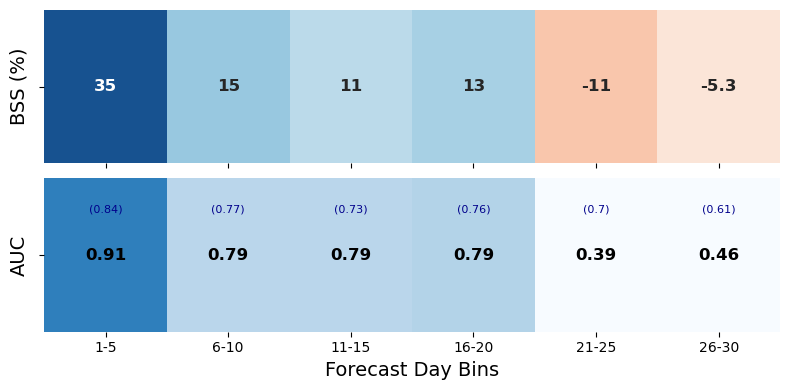

Figure saved as 'skill_scores_heatmap_gencast_30day.png'


In [ ]:
# Save results
model_name = 'gencast'  # Update with your model name
#save_dir = '/Users/mesfind/opt/Research/uchicago/ETAgroMetAIx/HCWF/ETAgroMetAIx/Training/ai-weather/ai_weather/reports/figures/gencast_results'
save_dir = None
print("\n7. Saving results...")
overall_file, binned_file = save_results(
    auc_forecast, brier_forecast, skill_results, rps_forecast,
    auc_climatology, brier_climatology, model_name, max_forecast_day,
    save_dir=save_dir
)

# Create heatmap
print("\n8. Creating heatmap...")
heatmap_file = create_heatmap(
    skill_results, auc_forecast, auc_climatology,
    brier_forecast, brier_climatology, model_name, max_forecast_day,
    save_dir=save_dir
)


## Discussions & Questions

1. How does the skill change for two smaller regions within this box: say **(i) 7.5N-10.25N; 37.5E-40E** and **(i) 10.5N-13.5N; 37.5E-40E** 

2. Using the same framework, benchmark another AWIP -- AIFS-ENS and compare the results for the same region with GenCast. 